# Analysis Notebook

# Setup

In [ ]:
packages <- c("emmeans","DescTools", "coin","XNomial","brms","nnet","lme4","multcompView","patchwork","janitor","lubridate","stringr","tidyverse","dplyr","ggplot2","readxl","writexl","readr")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

invisible(lapply(packages, quiet_load))


# Build DF’s into long format

In [ ]:

df_exp1_single_long <- df_exp1_single_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = matches("_(l0|l1)$"),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS),
    structure_type     = factor(structure, levels = STRUCTURE_LEVELS)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, size_mm1, weight_g1, date, stage, t_leave_s, t_l0_s, location_code, structure_type,legs1, claws1, antenna1, size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp1_single_long, "df_exp1_single_long.csv")

# EXP 2 – Group structure (long)
df_exp2_group_long <- df_exp2_group_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = c(location_l0, location_l1,
      structure_l0, structure_l1,legs_l0, claws_l0, antenna_l0,legs_l1, claws_l1, antenna_l1), names_to = c(".value", "stage"), names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage          = toupper(stage),
    location_code  = factor(toupper(location), levels = LOC_LEVELS),
    structure_type      = factor(structure, levels = STRUCTURE_LEVELS),
    size_mm_stage  = if_else(stage == "L0", size_mm1, size_mm2, NA_real_),
    weight_g_stage = if_else(stage == "L0", weight_g1, weight_g2, NA_real_)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date,stage, t_leave_s, t_l0_s, location_code, structure_type,legs, claws, antenna, size_mm_stage, weight_g_stage,size_mm1, weight_g1, legs1, claws1, antenna1,size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp2_group_long, "df_exp2_group_long.csv")


# EXP 3 – Stone / wood (long)
df_exp3_woodstone_long <- df_exp3_woodstone_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = c(location_l0, location_l1, structure_l0, structure_l1),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS3),
    structure_type     = factor(structure, levels = STRUCTURE_LEVELS3)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date, stage, location_code, structure_type, size_mm1, weight_g1, legs1, claws1, antenna1, size_mm2, weight_g2, legs2, claws2, antenna2, notes_exp, notes_koura)

write_out(df_exp3_woodstone_long, "df_exp3_woodstone_long.csv")


# EXP 4 – Bricks (long)
df_exp4_brick_long <- df_exp4_brick_raw %>%
  mutate(location_l1 = l1) %>%
  pivot_longer(cols = c(location_l1, structure_l1),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS),
    structure_type     = factor(structure, levels = STRUCTURE_LEVELS4)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date, stage, location_code, structure_type,size_mm1, weight_g1, legs1, claws1, antenna1,size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp4_brick_long, "df_exp4_brick_long.csv")


# Exp 1 Single koura

## Exp 1 Statistic

In [ ]:

# RQ 1: Is there a statistical difference between structure type in L1?
# RQ 2: Is there a preference within each sex?
# RQ 3: Does structure type differ between sex?
# RQ 4: Did structure type use shift directionally between L0 and L1?

df1 <- df_exp1_single_long %>%
  mutate(
    structure_type     = factor(structure_type),
    stage         = factor(stage, levels = c("L0", "L1")),
    sex           = factor(sex),
    size_class    = factor(size_class),
    location_code = factor(location_code),
    tank          = factor(tank),
    round         = factor(round),
    koura_id      = factor(koura_id),
    size_mm1      = as.numeric(size_mm1),
    weight_g1     = as.numeric(weight_g1)) %>%
  filter(!is.na(structure_type))

size_stats1 <- df1 %>%
  distinct(koura_id, sex, size_mm1, weight_g1) %>%
  group_by(sex) %>%
  summarise(mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
    sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
    min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
    max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
    mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
    sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
    min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
    max_wt   = round(max(weight_g1,  na.rm = TRUE), 1),
    .groups  = "drop") %>%
  bind_rows(df1 %>%
      distinct(koura_id, size_mm1, weight_g1) %>%
      summarise(sex = "Total",
        mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
        sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
        min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
        max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
        mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
        sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
        min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
        max_wt   = round(max(weight_g1,  na.rm = TRUE), 1)))


df1_L1 <- df1 %>% filter(stage == "L1" , structure_type != "TankWall") %>%
  mutate(structure_type = droplevels(structure_type))

pct_wood_overall <- round(mean(df1_L1$structure_type == "WoodLog") * 100)
pct_wood_male    <- round(mean(df1_L1$structure_type[df1_L1$sex == "M"] == "WoodLog") * 100)
pct_wood_female  <- round(mean(df1_L1$structure_type[df1_L1$sex == "F"] == "WoodLog") * 100)
pct_wall1 <- round(sum(df1$structure_type == "TankWall" & df1$stage == "L1") / sum(df1$stage == "L1") * 100)

# RQ1 — structure type preference at L1
tab1_L1 <- table(df1_L1$structure_type)
tab1_L1_nz <- tab1_L1[tab1_L1 > 0]

xmulti1 <- XNomial::xmulti(obs  = as.numeric(tab1_L1_nz), expr = rep(sum(tab1_L1_nz) / length(tab1_L1_nz), length(tab1_L1_nz)))



P value (LLR) = 1.57e-05


P value (LLR) = 0.09743


P value (LLR) = 5.454e-05

## Exp 1 Figure

systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfonts

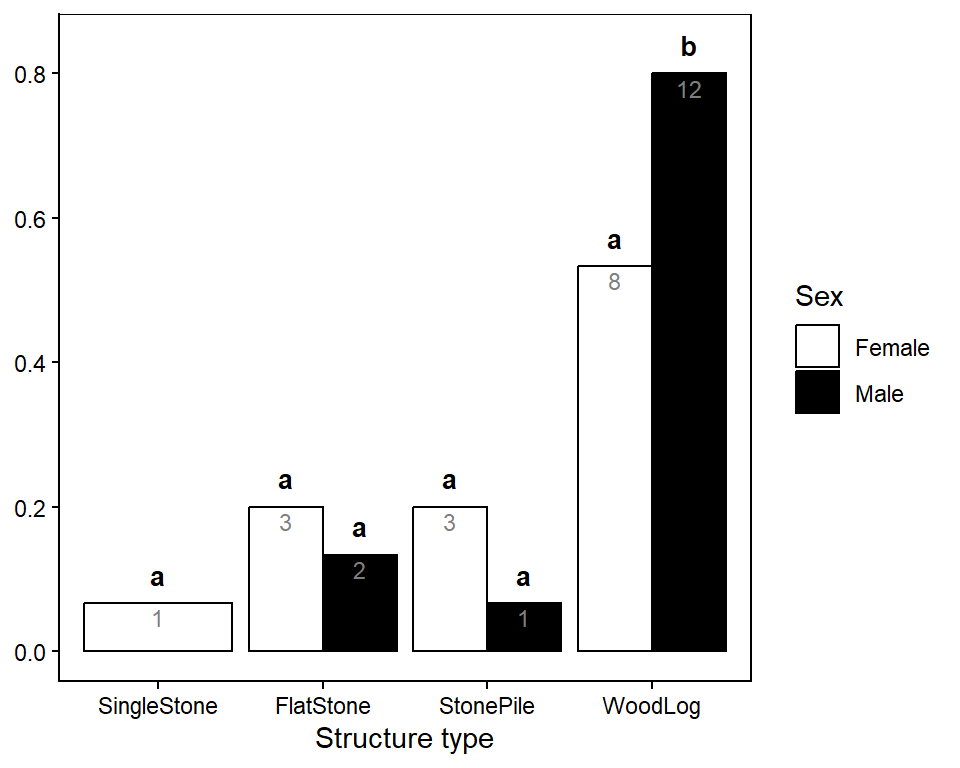

In [ ]:

exp1_structure_combined <- df_exp1_single_long %>%
  filter(stage == "L1") %>%
  count(stage, structure_type, name = "n") %>%
  group_by(stage) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_structure() %>%
  mutate(panel = "Combined")

exp1_structure_letters <- exp1_structure_combined %>%
  relevel_structure() %>%
  filter(stage == "L1") %>%
  left_join(cld_all1, by = c("stage", "panel", "structure_type"))

exp1_p_combined <- exp1_structure_combined %>%
  relevel_structure() %>%
  ggplot(aes(structure_type, prop)) +
  geom_col(color = "black") +
  geom_text(aes(label = n), vjust = 1.3, colour = "white", size = 3) +
  geom_text(data = exp1_structure_letters %>% filter(panel == "Combined"),
    aes(y = prop + 0.04, label = cld_letter), size = 3.5, fontface = "bold") +
  labs(x = "Structure type", y = "Proportion (L1)")



exp1_structure_bysex <- df_exp1_single_long %>%
  filter(stage == "L1") %>%
  count(stage, structure_type, sex, name = "n") %>%
  group_by(stage, sex) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_structure() %>%
  mutate(panel = dplyr::recode(sex, F = "Female", M = "Male")) %>%
  select(-sex)

exp1_structure_letters_sex <- exp1_structure_bysex %>%
  left_join(cld_all1, by = c("stage", "panel", "structure_type"))

exp1_p_sex <- exp1_structure_bysex %>%
  relevel_structure() %>%
  ggplot(aes(structure_type, prop, fill = panel)) +
  geom_col(color = "black", position = position_dodge(0.9)) +
  geom_text(aes(label = n), position = position_dodge(0.9), vjust = 1.3, colour = "grey50", size = 3) +
  geom_text(data = exp1_structure_letters_sex,  aes(y = prop + 0.04, label = cld_letter), position = position_dodge(0.9), size = 3.5, fontface = "bold") +
  scale_fill_manual(values = c(Female = "white", Male = "black"), name = "Sex") +
  labs(x = "Structure type", y = NULL) 

exp1_structure_p <- exp1_p_combined + exp1_p_sex 

ggsave(exp1_p_sex, file = file.path(out_dir, "fig-exp1.png"), width = 5, height = 4, dpi = 300)


## Exp 1 II

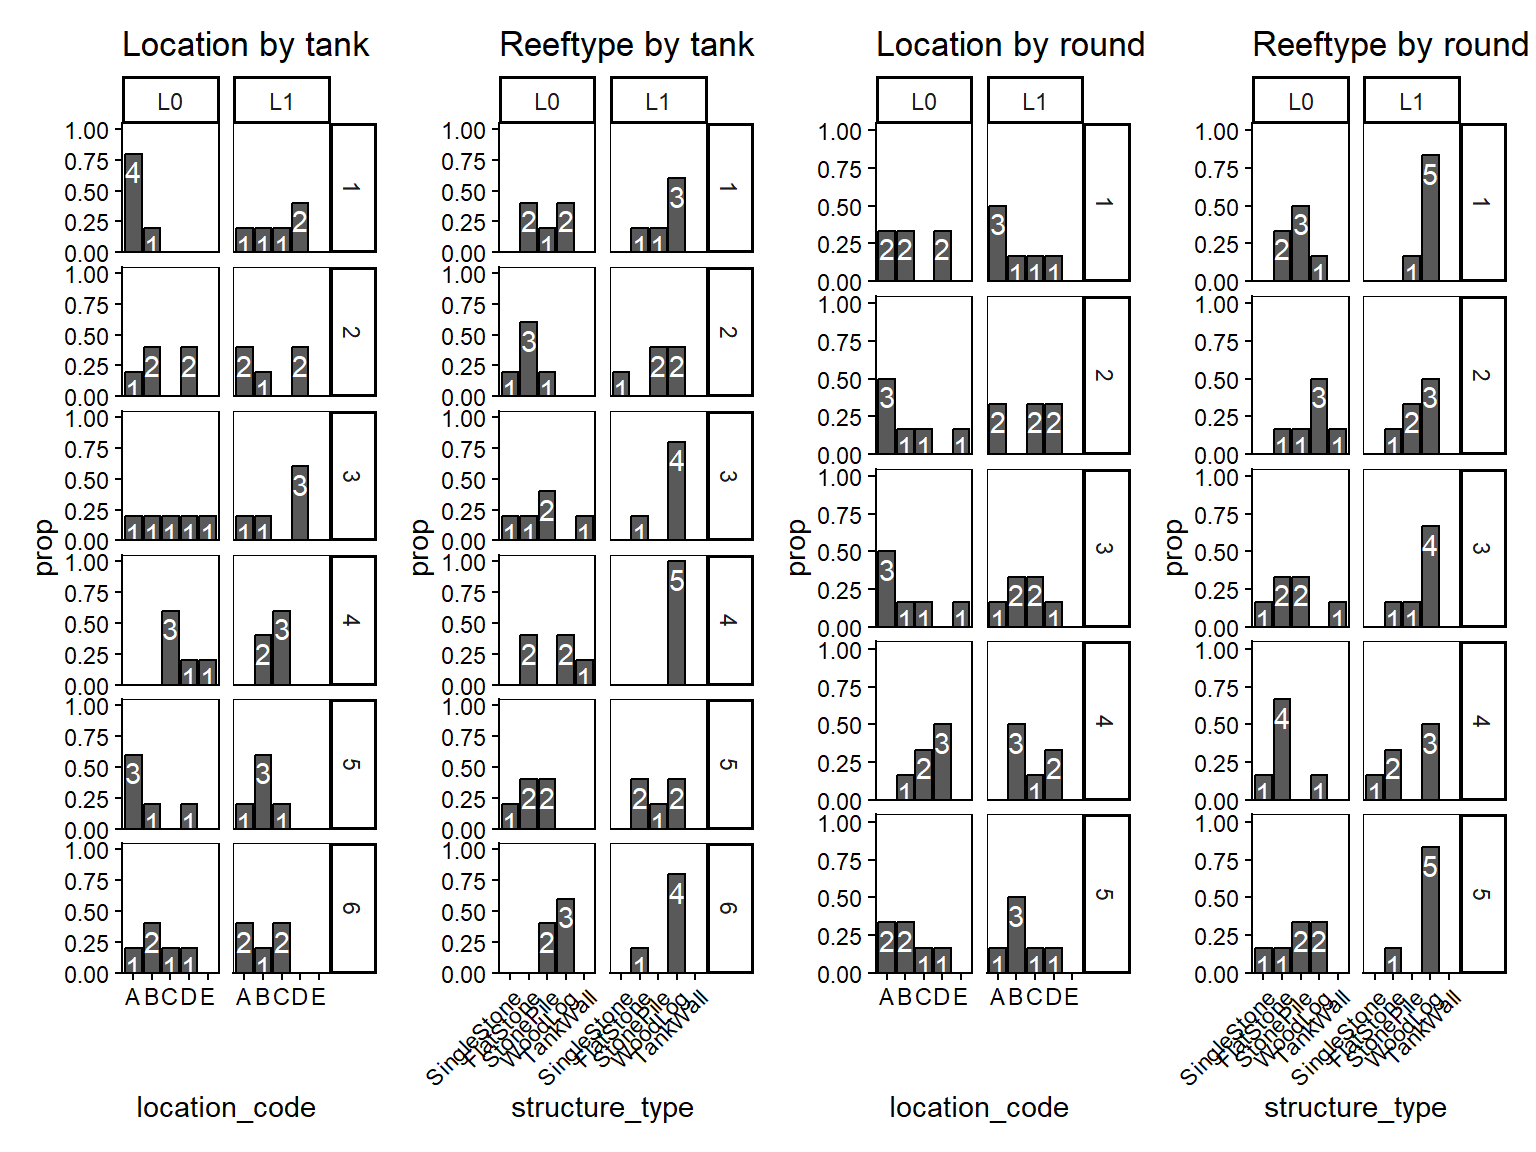

In [ ]:

invisible(capture.output({
  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

  # bar plot; rows = facetvar, cols = stage; fixed y-scale across all plots
  mk_bar <- function(df, xvar, facetvar, title, structure = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title) +
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (structure) {
      p <- p +
        scale_x_discrete(limits = STRUCTURE_LEVELS, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }

  # data
  exp1_loc    <- mk_props(df_exp1_single_long, location_code, tank)
  exp1_round  <- mk_props(df_exp1_single_long, location_code, round)
  exp1_loc2   <- mk_props(df_exp1_single_long, structure_type,     tank)
  exp1_round2 <- mk_props(df_exp1_single_long, structure_type,     round)

  # plots
  p_exp1_loc    <- mk_bar(exp1_loc,   location_code, tank,  "Location by tank")
  p_exp1_round  <- mk_bar(exp1_round, location_code, round, "Location by round")
  p_exp1_loc2   <- mk_bar(exp1_loc2,  structure_type,     tank,  "Reeftype by tank",  structure = TRUE)
  p_exp1_round2 <- mk_bar(exp1_round2,structure_type,     round, "Reeftype by round", structure = TRUE)

  loc_round_plots_exp1 <<- p_exp1_loc + p_exp1_loc2 + p_exp1_round + p_exp1_round2 +
    patchwork::plot_layout(ncol = 4)
}))

ggsave(loc_round_plots_exp1, file = file.path(out_dir, "fig-exp1-tank-round.png"), width = 10, height = 7, dpi = 300)

loc_round_plots_exp1


## Exp 1 III

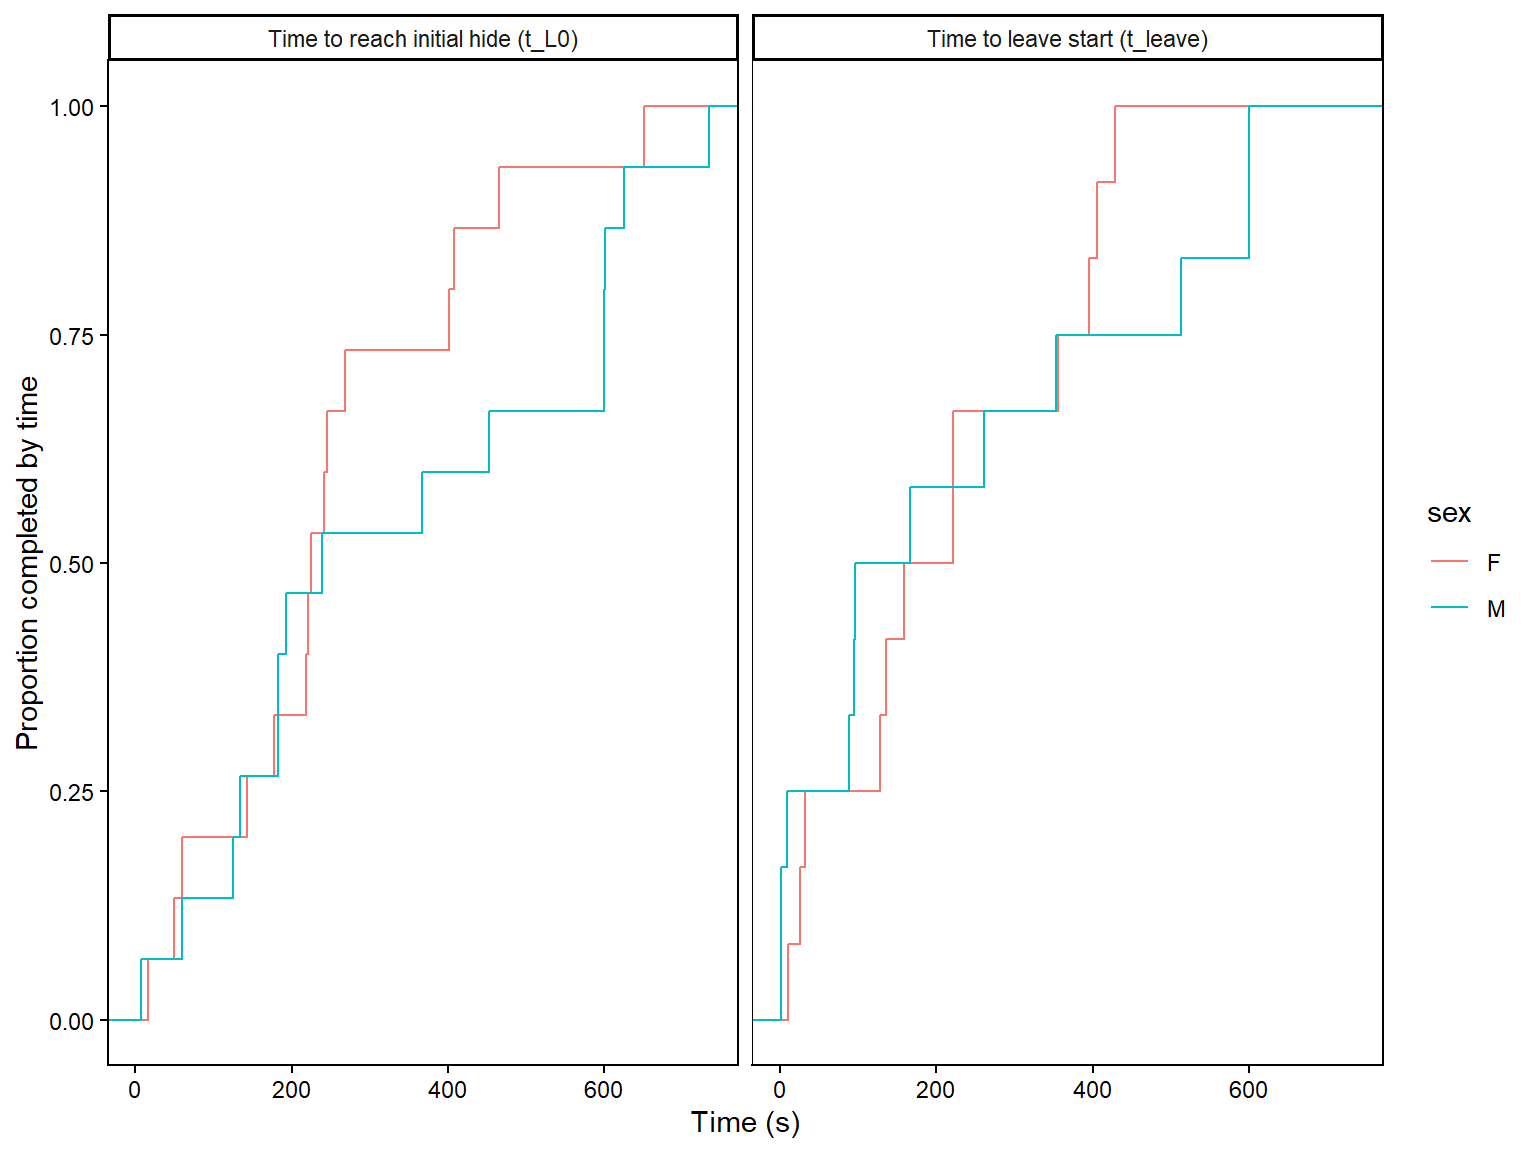

In [ ]:

exp1_pairs <- df_exp1_single_long %>%
  dplyr::filter(stage %in% c("L0","L1")) %>%
  dplyr::select(koura_id, tank, round, size_class, sex, stage,location_code, structure_type, t_leave_s, t_l0_s) %>%
  dplyr::mutate(
    location_code = forcats::fct_drop(factor(location_code, levels = LOC_LEVELS)),
    structure_type     = forcats::fct_drop(factor(structure_type,     levels = STRUCTURE_LEVELS)),
    t_leave_s     = suppressWarnings(as.numeric(t_leave_s)),
    t_l0_s        = suppressWarnings(as.numeric(t_l0_s))) %>%
  tidyr::pivot_wider(names_from = stage,values_from = c(location_code, structure_type, t_leave_s, t_l0_s),names_sep = "_")

activity_df <- exp1_pairs %>%
  dplyr::transmute(koura_id, tank, round, size_class, sex, time_to_leave = t_leave_s_L0, time_at_L0 = t_l0_s_L0) 

activity_long <- activity_df %>%
  mutate(
    time_to_leave = suppressWarnings(as.numeric(time_to_leave)),time_at_L0    = suppressWarnings(as.numeric(time_at_L0))) %>%
  pivot_longer(c(time_to_leave, time_at_L0), names_to = "metric", values_to = "time") %>%
  filter(!is.na(time), time >= 0)

lab_metric <- c(time_to_leave = "Time to leave start (t_leave)",
                time_at_L0    = "Time to reach initial hide (t_L0)")

act_exp1_p <- ggplot(activity_long, aes(time, col=sex)) +
  stat_ecdf(geom = "step") +
  facet_grid( ~ metric, labeller = labeller(metric = lab_metric)) +
  labs(x = "Time (s)", y = "Proportion completed by time")

act_exp1_p


# Exp 2 Group koura

## Exp 2 Statistic

In [ ]:

# RQ 1: Does overall structure preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does size class affect structure preference?            (brms categorical)
# RQ 3: Which structure is most preferred per size class?       (Posterior probabilities from brms)
# RQ 4: Did preference shift directionally L0→L1?          (Stuart-Maxwell)

df2 <- df_exp2_group_long %>%
  mutate(
    structure_type  = factor(structure_type),
    stage      = factor(stage, levels = c("L0", "L1")),
    sex        = factor(sex),
    size_class = factor(size_class, levels = c("S", "M", "L")),
    location_code = factor(location_code),
    tank       = factor(tank),
    round      = factor(round),
    group_id   = factor(group_id),
    koura_id   = factor(koura_id)) %>%
  filter(!is.na(structure_type))

size_stats2 <- df2 %>%
  distinct(koura_id, size_class, size_mm1, weight_g1) %>%
  group_by(size_class) %>%
  summarise(mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
    sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
    min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
    max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
    mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
    sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
    min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
    max_wt   = round(max(weight_g1,  na.rm = TRUE), 1),
    .groups  = "drop") %>%
  bind_rows(df2 %>%
      distinct(koura_id, size_mm1, weight_g1) %>%
      summarise(size_class = "Total",
        mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
        sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
        min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
        max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
        mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
        sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
        min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
        max_wt   = round(max(weight_g1,  na.rm = TRUE), 1)))

pct_wall2 <- round(sum(df2$structure_type == "TankWall" & df2$stage == "L1") /
  sum(df2$stage == "L1") * 100)


# RQ1 — Overall structure preference at group level
df2_grp <- df2 %>%
  filter(stage == "L1") %>%
  count(group_id, round, structure_type) %>%
  complete(group_id, round, structure_type, fill = list(n = 0)) %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

# Test whether proportion at each structure type differs from uniform (0.25)
wilcox_flat  <- wilcox.test(df2_grp$prop[df2_grp$structure_type == "FlatStone"],  mu = 0.25, exact = FALSE)
wilcox_pile  <- wilcox.test(df2_grp$prop[df2_grp$structure_type == "StonePile"],  mu = 0.25, exact = FALSE)
wilcox_wood  <- wilcox.test(df2_grp$prop[df2_grp$structure_type == "WoodLog"],    mu = 0.25, exact = FALSE)
wilcox_single <- wilcox.test(df2_grp$prop[df2_grp$structure_type == "SingleStone"], mu = 0.25, exact = FALSE)

p_wilcox2_adjusted <- p.adjust(
  c(p_wilcox_flat   = wilcox_flat$p.value,
    p_wilcox_single = wilcox_single$p.value,
    p_wilcox_pile   = wilcox_pile$p.value,
    p_wilcox_wood   = wilcox_wood$p.value),
  method = "bonferroni")
#p_wilcox2_adjusted

# Extract named values for inline use
p_wilcox2_flat   <- p_wilcox2_adjusted["p_wilcox_flat"]
p_wilcox2_single <- p_wilcox2_adjusted["p_wilcox_single"]
p_wilcox2_pile   <- p_wilcox2_adjusted["p_wilcox_pile"]
p_wilcox2_wood   <- p_wilcox2_adjusted["p_wilcox_wood"]

# Direct comparison FlatStone vs StonePile at group level
fs_props <- df2_grp %>% filter(structure_type == "FlatStone") %>% pull(prop)
sp_props <- df2_grp %>% filter(structure_type == "StonePile") %>% pull(prop)

wilcox_fs_vs_sp <- wilcox.test(fs_props, sp_props, paired = TRUE, exact = FALSE)
p_fs_vs_sp <- wilcox_fs_vs_sp$p.value
#p_fs_vs_sp


# RQ2 — Does size class affect structure preference?
# Model last fit: 2026-5-25
# Delete m2_size_bayes.rds to refit

# Path to saved model
m_path2 <- file.path(der_data_dir, "m_exp2_bayes.rds")

# Only fit if model file doesn't exist
if (!file.exists(m_path2)) {
  m_exp2_bayes <- brm(
    structure_type ~ size_class + (1 | group_id/koura_id) + (1 | round),
    data          = df2 %>% filter(stage == "L1"),
    family        = categorical(),
    cores         = 4,
    iter          = 4000,
    open_progress = FALSE,
    control       = list(adapt_delta = 0.99, max_treedepth = 12))
  saveRDS(m_exp2_bayes, m_path2)
} else {
  m_exp2_bayes <- readRDS(m_path2)
}

# Diagnostics
nuts_params(m_exp2_bayes) %>% filter(Parameter == "divergent__") %>% summarise(sum(Value))


  sum(Value)
1          0

 Family: categorical 
  Links: muFlatStone = logit; muStonePile = logit; muWoodLog = logit 
Formula: reef_type ~ size_class + (1 | group_id/koura_id) + (1 | round) 
   Data: df2 %>% filter(stage == "L1") (Number of observations: 180) 
  Draws: 4 chains, each with iter = 4000; warmup = 2000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~group_id (Number of levels: 6) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muFlatStone_Intercept)     0.26      0.25     0.01     0.92 1.00     4235
sd(muStonePile_Intercept)     0.33      0.31     0.01     1.13 1.00     3802
sd(muWoodLog_Intercept)       0.46      0.38     0.02     1.43 1.00     3670
                          Tail_ESS
sd(muFlatStone_Intercept)     4283
sd(muStonePile_Intercept)     4401
sd(muWoodLog_Intercept)       4231

~group_id:koura_id (Number of levels: 36) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muFlatStone_Intercept)  

                          Estimate Est.Error       Q2.5       Q97.5
muFlatStone_Intercept    2.7744367 0.8220913  1.3752853  4.58226182
muStonePile_Intercept    2.1388863 0.8731525  0.5985997  4.03589200
muWoodLog_Intercept      1.6165862 0.9897825 -0.2420960  3.65711137
muFlatStone_size_classM -1.7486703 0.9090147 -3.6552677 -0.08621181
muFlatStone_size_classL -0.9718334 0.9690964 -2.9926701  0.82634480
muStonePile_size_classM -1.4171356 0.9411656 -3.4233546  0.29874691
muStonePile_size_classL -0.4212932 0.9888826 -2.4797980  1.40641966
muWoodLog_size_classM   -0.9181904 0.9565192 -2.9077924  0.82976379
muWoodLog_size_classL   -1.1334491 1.0414715 -3.2696829  0.85326077

## Exp 2 Table

In [ ]:

fixef(m_exp2_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)


  Parameter                    Mean     SD    2.5%   97.5%
  ------------------------- ------- ------ ------- -------
  muFlatStone_Intercept        2.77   0.82    1.38    4.58
  muStonePile_Intercept        2.14   0.87    0.60    4.04
  muWoodLog_Intercept          1.62   0.99   -0.24    3.66
  muFlatStone_size_classM     -1.75   0.91   -3.66   -0.09
  muFlatStone_size_classL     -0.97   0.97   -2.99    0.83
  muStonePile_size_classM     -1.42   0.94   -3.42    0.30
  muStonePile_size_classL     -0.42   0.99   -2.48    1.41
  muWoodLog_size_classM       -0.92   0.96   -2.91    0.83
  muWoodLog_size_classL       -1.13   1.04   -3.27    0.85


## Exp 2 Figure

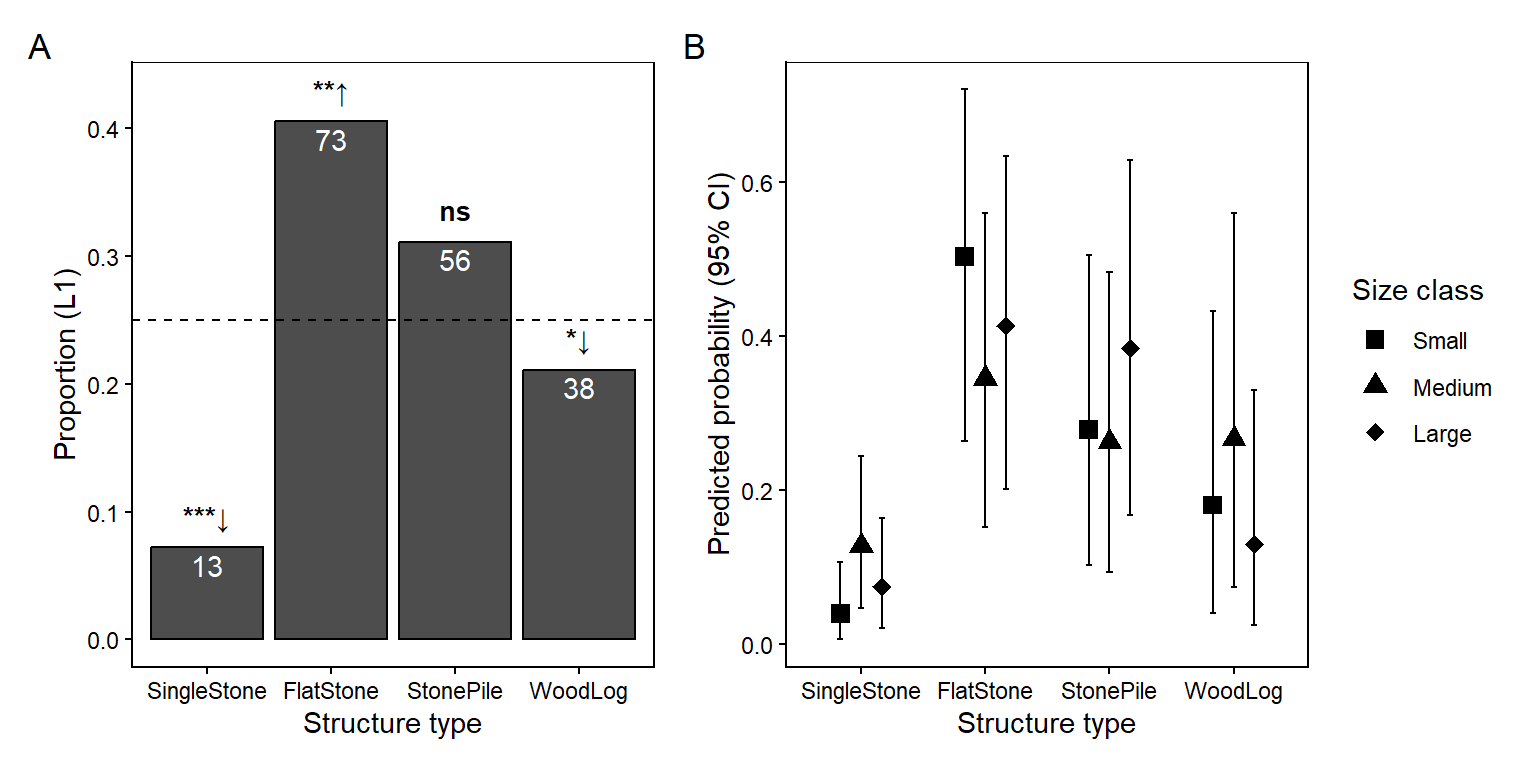

In [ ]:

exp2_combined <- df_exp2_group_long %>%
  filter(stage == "L1") %>%
  count(structure_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_structure() %>%
  mutate(panel = "Combined")

# Wilcoxon significance
ann_wilcox2 <- data.frame(
  structure_type = c("SingleStone", "FlatStone", "StonePile", "WoodLog"),
  label     = c(sig_label(p_wilcox2_adjusted["p_wilcox_single"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_flat"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_pile"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_wood"]))) %>%
  mutate(structure_type = factor(structure_type, levels = STRUCTURE_LEVELS)) %>%
  left_join(exp2_combined %>% select(structure_type, prop), by = "structure_type") %>%
  mutate(y = prop + 0.025, label = case_when(
           structure_type == "FlatStone" & label != "ns" ~ paste0(label, "↑"), structure_type %in% c("SingleStone", "WoodLog") & label != "ns" ~ paste0(label, "↓"), TRUE ~ label))

Exp2_combined_p <- exp2_combined %>%
  relevel_structure() %>%
  ggplot(aes(structure_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = 0.25, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox2, aes(x = structure_type, y = y, label = label), size = 3.5, fontface = "bold") +
  #scale_y_continuous(limits = c(0, 0.7)) +
  labs(x = "Structure type", y = "Proportion (L1)", tag = "A")

ce2_p <- pp_summary2 %>%
  filter(structure_type != "TankWall") %>%
  relevel_structure() %>%
  mutate(size_class = factor(size_class, levels = c("S", "M", "L"))) %>%
  ggplot(aes(structure_type, mean_prob, shape = size_class, group = size_class)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 3, position = position_dodge(0.5)) +
  scale_shape_manual(values = size_shape_map, labels = c(S = "Small", M = "Medium", L = "Large")) +
  labs(x = "Structure type", y = "Predicted probability (95% CI)", shape = "Size class", tag = "B")


# Combine plots
Exp2_p <- Exp2_combined_p | ce2_p 

ggsave(Exp2_p, file = file.path(out_dir, "fig-exp2.png"), width = 8, height = 4, dpi = 300)

Exp2_p


## Exp 2 II

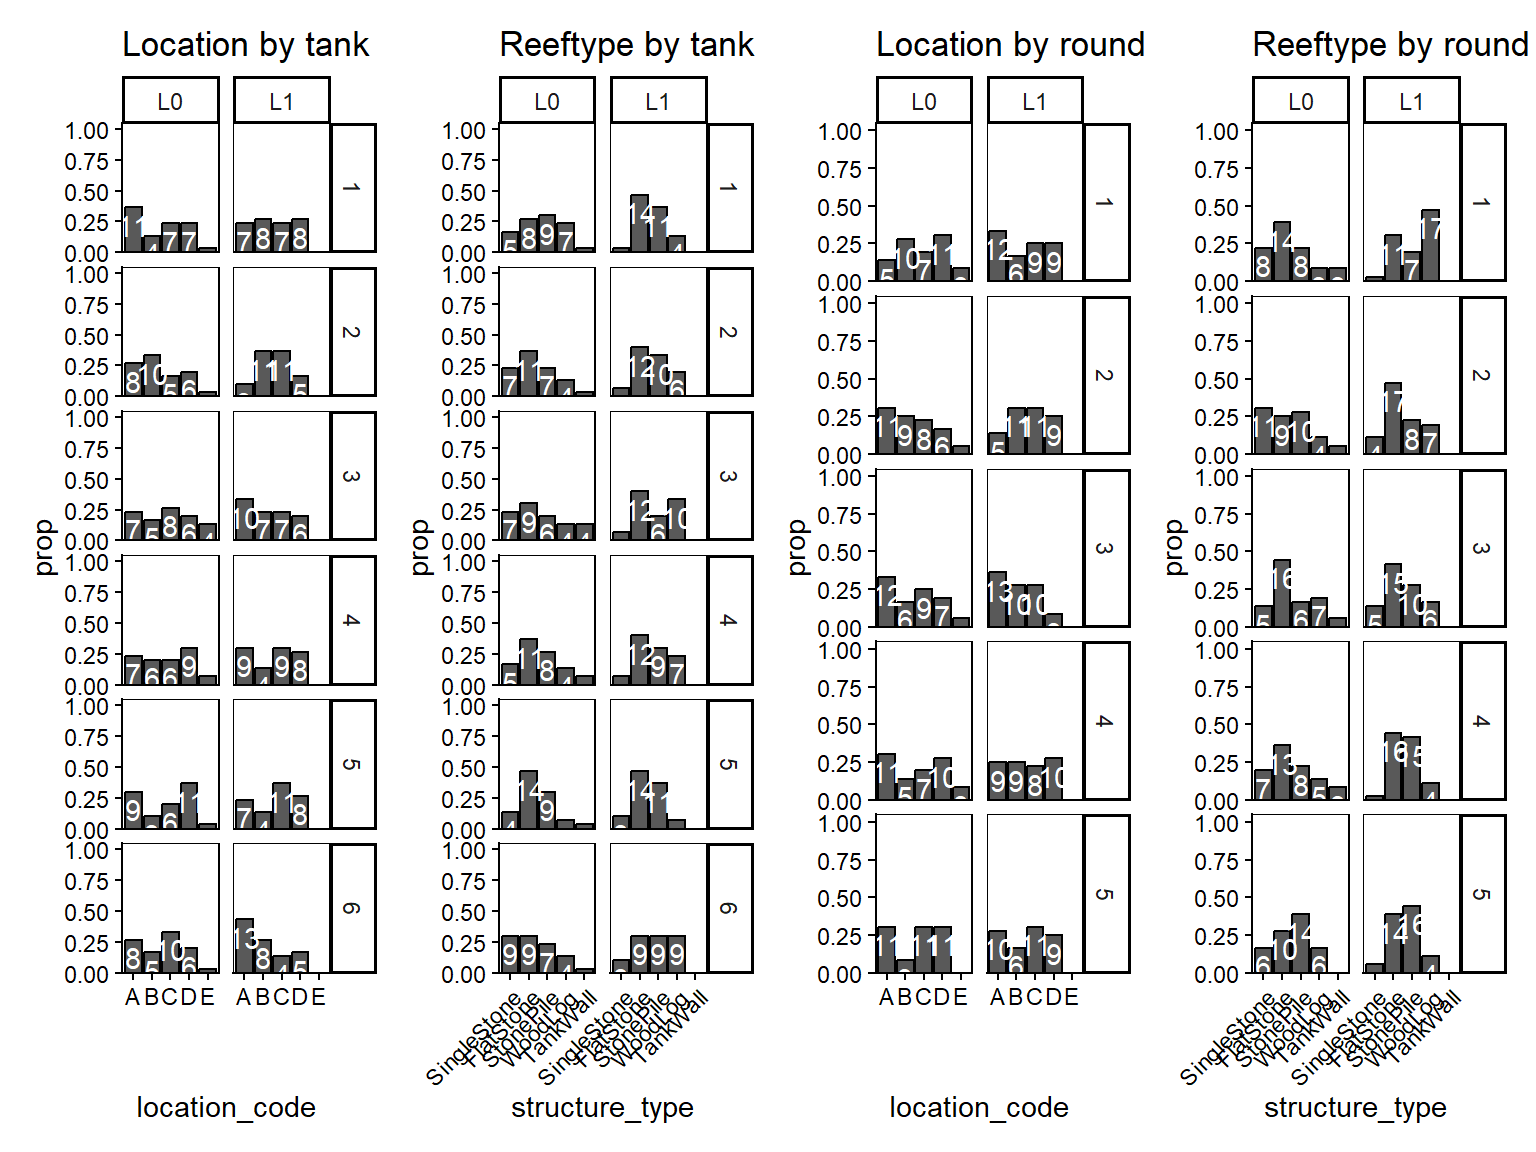

In [ ]:

invisible(capture.output({

  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

  # bar plot; uses facet_grid for rows=facetvar, cols=stage
  mk_bar <- function(df, xvar, facetvar, title, structure = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title)+
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (structure) {
      p <- p +
        scale_x_discrete(limits = STRUCTURE_LEVELS, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }

  # data
  exp2_loc    <- mk_props(df_exp2_group_long, location_code, tank)
  exp2_round  <- mk_props(df_exp2_group_long, location_code, round)
  exp2_loc2   <- mk_props(df_exp2_group_long, structure_type,     tank)
  exp2_round2 <- mk_props(df_exp2_group_long, structure_type,     round)

  # plots
  p_exp2_loc    <- mk_bar(exp2_loc,   location_code, tank,  "Location by tank")
  p_exp2_round  <- mk_bar(exp2_round, location_code, round, "Location by round")
  p_exp2_loc2   <- mk_bar(exp2_loc2,  structure_type,     tank,  "Reeftype by tank",  structure = TRUE)
  p_exp2_round2 <- mk_bar(exp2_round2,structure_type,     round, "Reeftype by round", structure = TRUE)

  loc_round_plots_exp2 <<- p_exp2_loc + p_exp2_loc2 + p_exp2_round + p_exp2_round2 +
    patchwork::plot_layout(ncol = 4)
}))

ggsave(loc_round_plots_exp2, file = file.path(out_dir, "fig-exp2-tank-round.png"), width = 10, height = 7, dpi = 300)

loc_round_plots_exp2


## Exp 2 III

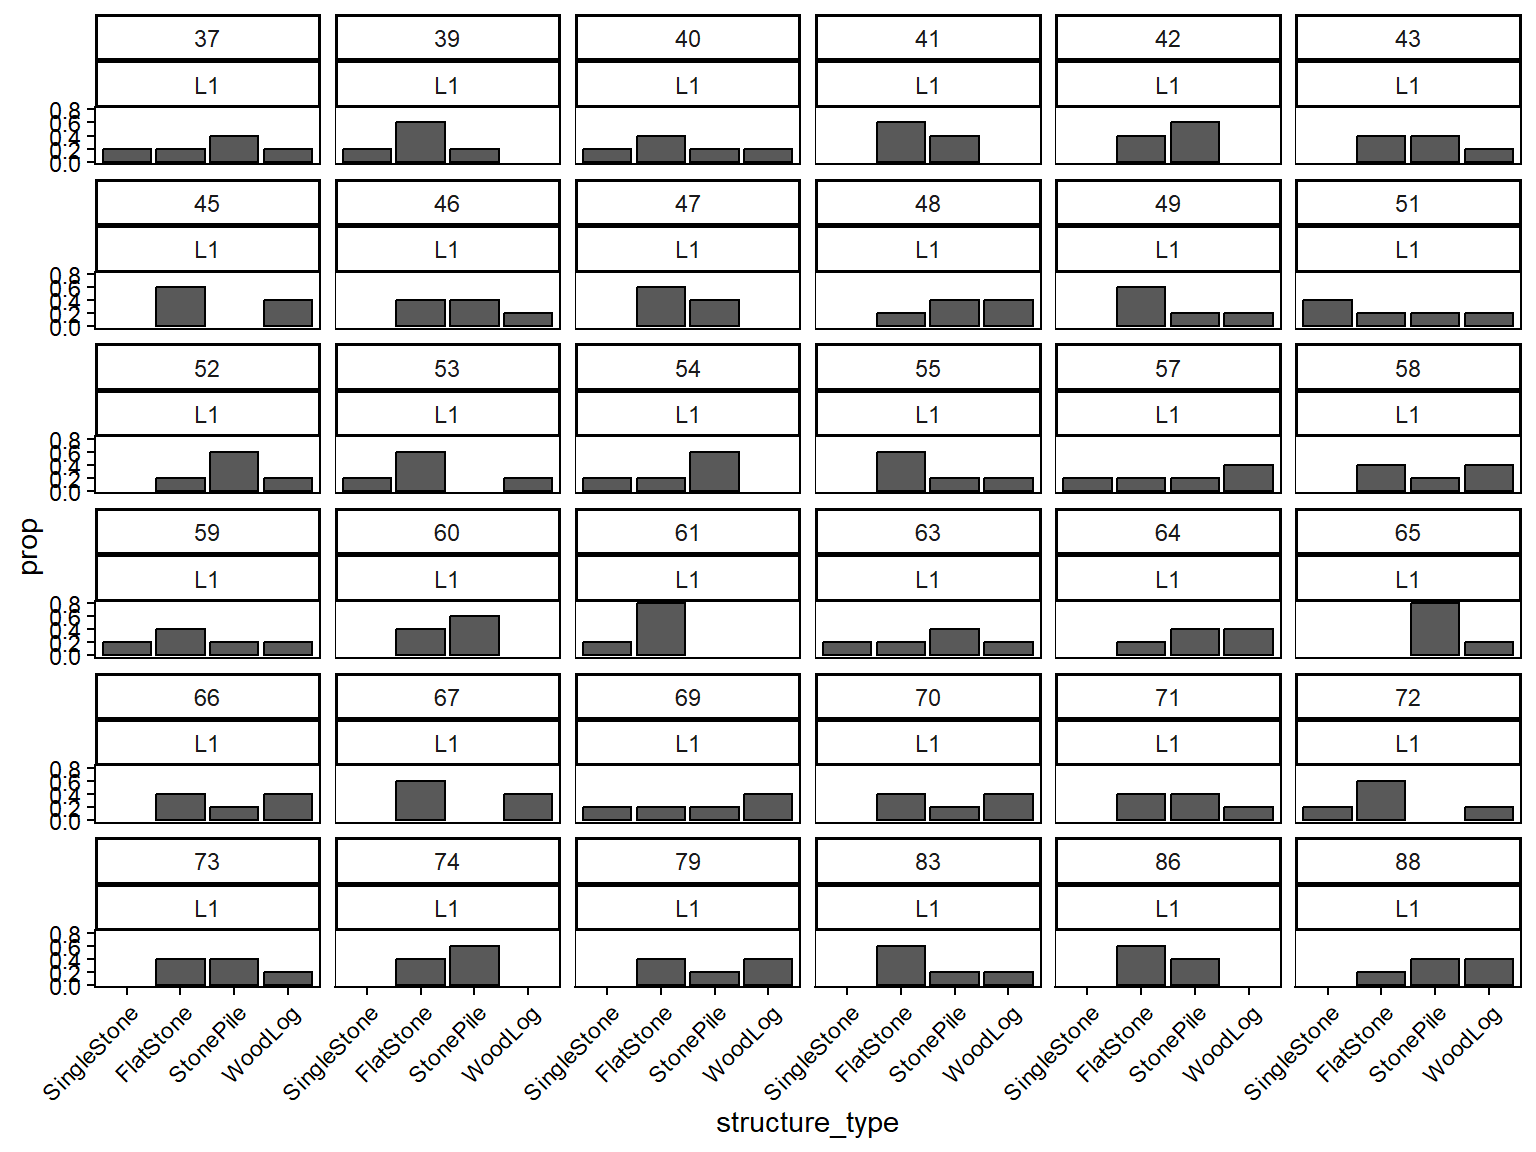

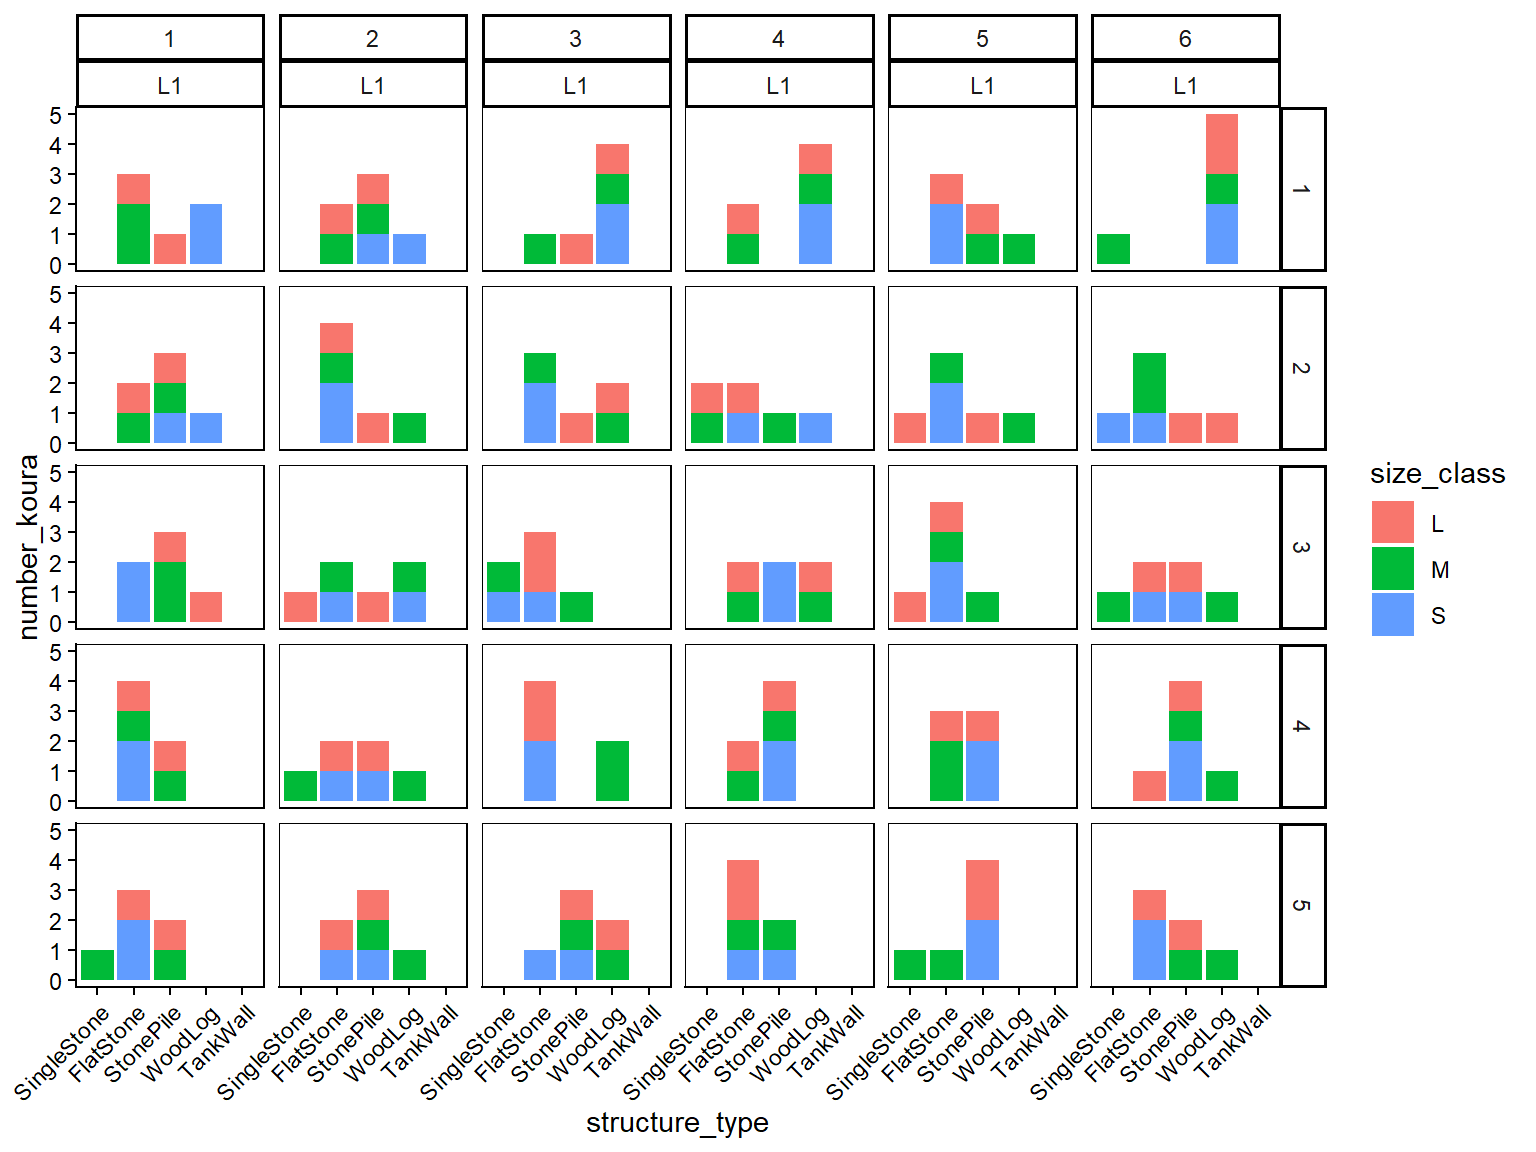

In [ ]:

exp2_structure_koura <- df_exp2_group_long %>%
  mutate(stage = toupper(stage)) %>%
  filter(stage == "L1") %>%
  count(stage, structure_type, koura_id, name = "n") %>%
  group_by(stage, koura_id) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_structure()

p_exp2_structure_koura <- exp2_structure_koura %>%
  relevel_structure() %>%
  ggplot(aes(structure_type, prop)) +
  geom_col(color = "black") +
  facet_wrap(koura_id ~ stage, nrow = 6) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_exp2_structure_koura


exp2_use <- df_exp2_group_long %>% 
  filter(stage == "L1")

counts <- exp2_use %>%
  filter(!is.na(structure_type), !is.na(size_class)) %>%
  mutate(
    tank = factor(tank),
    round = factor(round),
    stage = factor(stage),
    structure_type  = fct_relevel(structure_type,"SingleStone","FlatStone","StonePile","WoodLog","TankWall"),
    size_class = factor(size_class)) %>%
  count(stage, round, tank, structure_type, size_class, name = "number_koura") %>%
  complete(stage, round, tank, structure_type, size_class, fill = list(number_koura = 0))

p_stack <- ggplot(counts, aes(structure_type, number_koura, fill = size_class)) +
  geom_col() +
  facet_grid(round ~ tank+stage  , scales = "free_x")+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_stack


# Exp 3 Wood vs stone

## Exp 3 Statistic

In [ ]:

# RQ 1: Does overall structure preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does size class affect structure preference?            (brms categorical)
# RQ 3: Which structure is most preferred per size class?       (Posterior probabilities from brms)
# RQ 4: Did preference shift directionally L0→L1?          (Stuart-Maxwell)

df3 <- df_exp3_woodstone_long %>%
  mutate(
    structure_type      = factor(structure_type),
    stage          = factor(stage, levels = c("L0", "L1")),
    sex            = factor(sex), # all male
    size_class     = factor(size_class, levels = c("S", "M", "L")),
    location_code  = factor(location_code),
    tank           = factor(tank),
    round          = factor(round),
    group_id       = factor(group_id),
    koura_id       = factor(koura_id)) %>%
  filter(!is.na(structure_type)) 

df3_L1 <- df3 %>% filter(stage == "L1", !is.na(structure_type), structure_type != "NA")

pct_wall3 <- round(sum(df3$structure_type == "TankWall" & df3$stage == "L1") / sum(df3$stage == "L1") * 100)

# RQ1 — Overall structure preference at group level
df3_grp <- df3_L1 %>%
  count(group_id, round, structure_type) %>%
  filter(structure_type != "TankWall") %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

wilcox3_flat  <- wilcox.test(df3_grp$prop[df3_grp$structure_type == "FlatStone"], mu = 0.5, exact = FALSE)
wilcox3_split <- wilcox.test(df3_grp$prop[df3_grp$structure_type == "WoodSplit"], mu = 0.5, exact = FALSE)

p_wilcox3_adjusted <- p.adjust(c(p_wilcox3_flat  = wilcox3_flat$p.value,p_wilcox3_split = wilcox3_split$p.value), method = "bonferroni")

#p_wilcox3_adjusted

# Extract named values for inline use
p_wilcox3_flat  <- p_wilcox3_adjusted["p_wilcox3_flat"]
p_wilcox3_split <- p_wilcox3_adjusted["p_wilcox3_split"]


# RQ2 — Does size class affect structure preference?
# Model last fit: 2026-5-25
# Delete m_exp3_bayes.rds to refit

df3_L1 <- df3_L1 %>% mutate(structure_type = relevel(factor(structure_type), ref = "FlatStone"))

m_path3 <- file.path(der_data_dir, "m_exp3_bayes.rds")

if (!file.exists(m_path3)) {
  m_exp3_bayes <- brm(
    structure_type ~ size_class + (1 | group_id/koura_id) + (1 | round),
    data = df3_L1 %>% filter(stage == "L1"),
    family = categorical(),
    cores = 4, iter = 4000, open_progress = FALSE,
    control = list(adapt_delta = 0.99, max_treedepth = 12))
  saveRDS(m_exp3_bayes, m_path3)
} else {
  m_exp3_bayes <- readRDS(m_path3)
}

# Diagnostics
nuts_params(m_exp3_bayes) %>% filter(Parameter == "divergent__") %>% summarise(sum(Value))


  sum(Value)
1          0

 Family: categorical 
  Links: muWoodSplit = logit; muTankWall = logit 
Formula: reef_type ~ size_class + (1 | group_id/koura_id) + (1 | round) 
   Data: df3_L1 %>% filter(stage == "L1") (Number of observations: 106) 
  Draws: 4 chains, each with iter = 4000; warmup = 2000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~group_id (Number of levels: 6) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muWoodSplit_Intercept)     0.42      0.40     0.02     1.43 1.00     3438
sd(muTankWall_Intercept)      2.33      3.17     0.08     8.34 1.00     5809
                          Tail_ESS
sd(muWoodSplit_Intercept)     2658
sd(muTankWall_Intercept)      4374

~group_id:koura_id (Number of levels: 36) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muWoodSplit_Intercept)     0.73      0.49     0.03     1.87 1.00     2059
sd(muTankWall_Intercept)      1.97      1.94     0.07     6.61 1.00     5206
  

                           Estimate   Est.Error        Q2.5      Q97.5
muWoodSplit_Intercept    -0.3821432   1.0069737   -2.252055  1.7864922
muTankWall_Intercept     -4.3137273   8.6917370  -16.722061 13.0082535
muWoodSplit_size_classM  -0.2969921   0.6643598   -1.621193  1.0139846
muWoodSplit_size_classL  -2.4000578   0.9026210   -4.385559 -0.7989628
muTankWall_size_classM  -33.4028090 114.7527918 -199.261282  1.0868787
muTankWall_size_classL  -22.1340060  35.8528415 -133.778443  0.8392832

[1] 0.67475

[1] 0.998625

## Exp 3 Table

In [ ]:

fixef(m_exp3_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)


  Parameter                     Mean       SD      2.5%   97.5%
  ------------------------- -------- -------- --------- -------
  muWoodSplit_Intercept        -0.38     1.01     -2.25    1.79
  muTankWall_Intercept         -4.31     8.69    -16.72   13.01
  muWoodSplit_size_classM      -0.30     0.66     -1.62    1.01
  muWoodSplit_size_classL      -2.40     0.90     -4.39   -0.80
  muTankWall_size_classM      -33.40   114.75   -199.26    1.09
  muTankWall_size_classL      -22.13    35.85   -133.78    0.84


## Exp 3 Figure

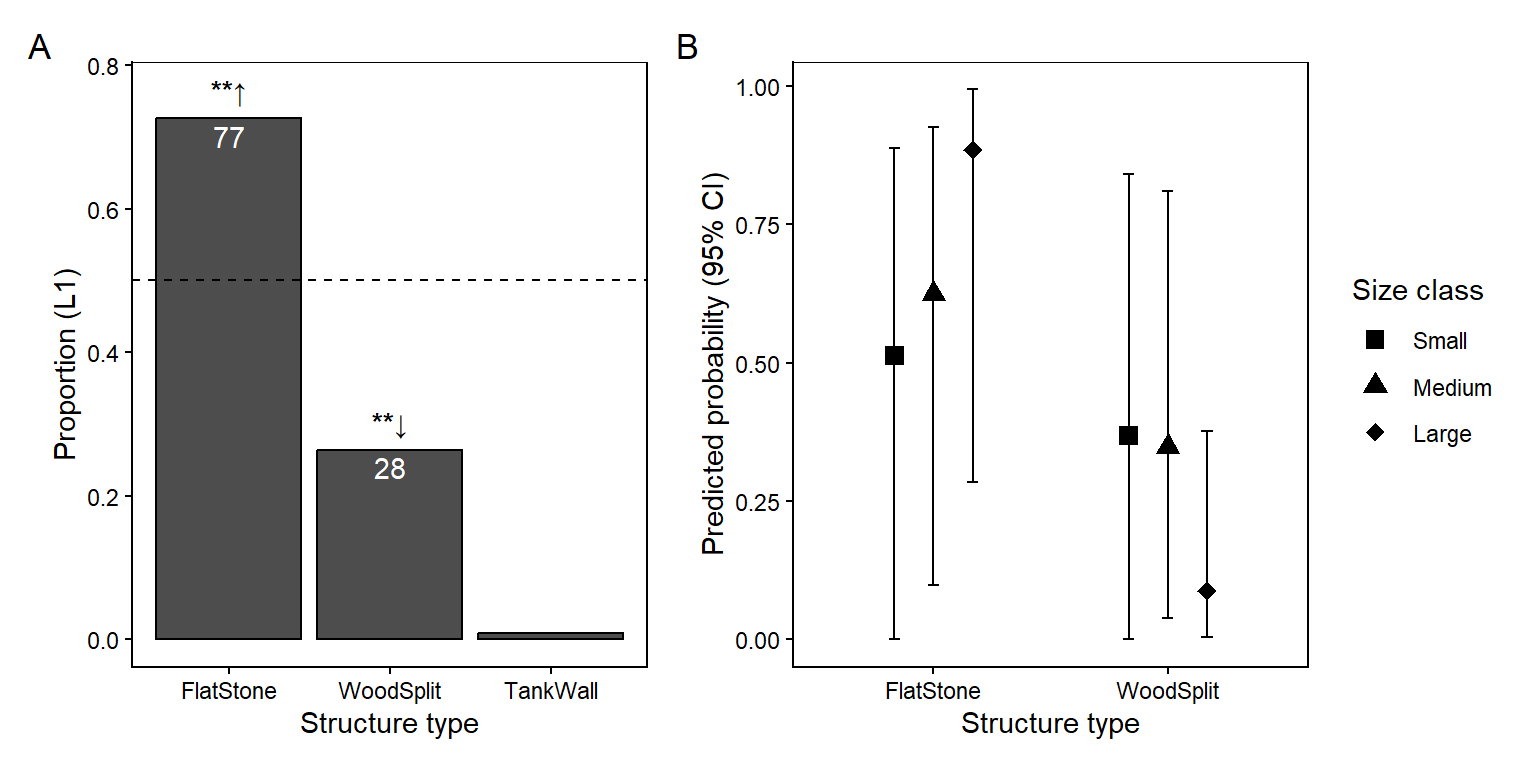

In [ ]:

exp3_combined <- df_exp3_woodstone_long %>%
  filter(stage == "L1", !is.na(structure_type), structure_type != "NA") %>%
  count(structure_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_structure3() %>%
  mutate(panel = "Combined")

ann_wilcox3 <- data.frame(
  structure_type = c("FlatStone", "WoodSplit"),
  label     = c(sig_label(p_wilcox3_adjusted["p_wilcox3_flat"]),
                sig_label(p_wilcox3_adjusted["p_wilcox3_split"]))) %>%
  mutate(structure_type = factor(structure_type, levels = STRUCTURE_LEVELS3)) %>%
  left_join(exp3_combined %>% select(structure_type, prop), by = "structure_type") %>%
  mutate(y = prop + 0.04, label = case_when( structure_type == "FlatStone" & label != "ns" ~ paste0(label, "↑"), structure_type %in% c("WoodSplit") & label != "ns" ~ paste0(label, "↓"), TRUE ~ label))

Exp3_combined_p <- exp3_combined %>%
  relevel_structure3() %>%
  ggplot(aes(structure_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = .5, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox3, aes(x = structure_type, y = y, label = label), size = 3.5, fontface = "bold") +
  #scale_y_continuous(limits = c(0, 0.85)) +
  labs(x = "Structure type", y = "Proportion (L1)", tag = "A")

ce3_p <- pp_summary3 %>%
  filter(structure_type != "NA", structure_type != "TankWall") %>%
  relevel_structure3() %>%
  mutate(size_class = factor(size_class, levels = c("S", "M", "L"))) %>%
  ggplot(aes(structure_type, mean_prob, shape = size_class, group = size_class)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 3, position = position_dodge(0.5)) +
  scale_shape_manual(values = size_shape_map, labels = c(S = "Small", M = "Medium", L = "Large")) +
  labs(x = "Structure type", y = "Predicted probability (95% CI)", shape = "Size class", tag = "B")

Exp3_p <- Exp3_combined_p | ce3_p

ggsave(Exp3_p, file = file.path(out_dir, "fig-exp3.png"), width = 8, height = 4, dpi = 300)
Exp3_p


## Exp 3 II

(`geom_col()`).

(`geom_text()`).

(`geom_col()`).

(`geom_text()`).

(`geom_col()`).
Removed 4 rows containing missing values or values outside the scale range
(`geom_text()`).

(`geom_col()`).

(`geom_text()`).

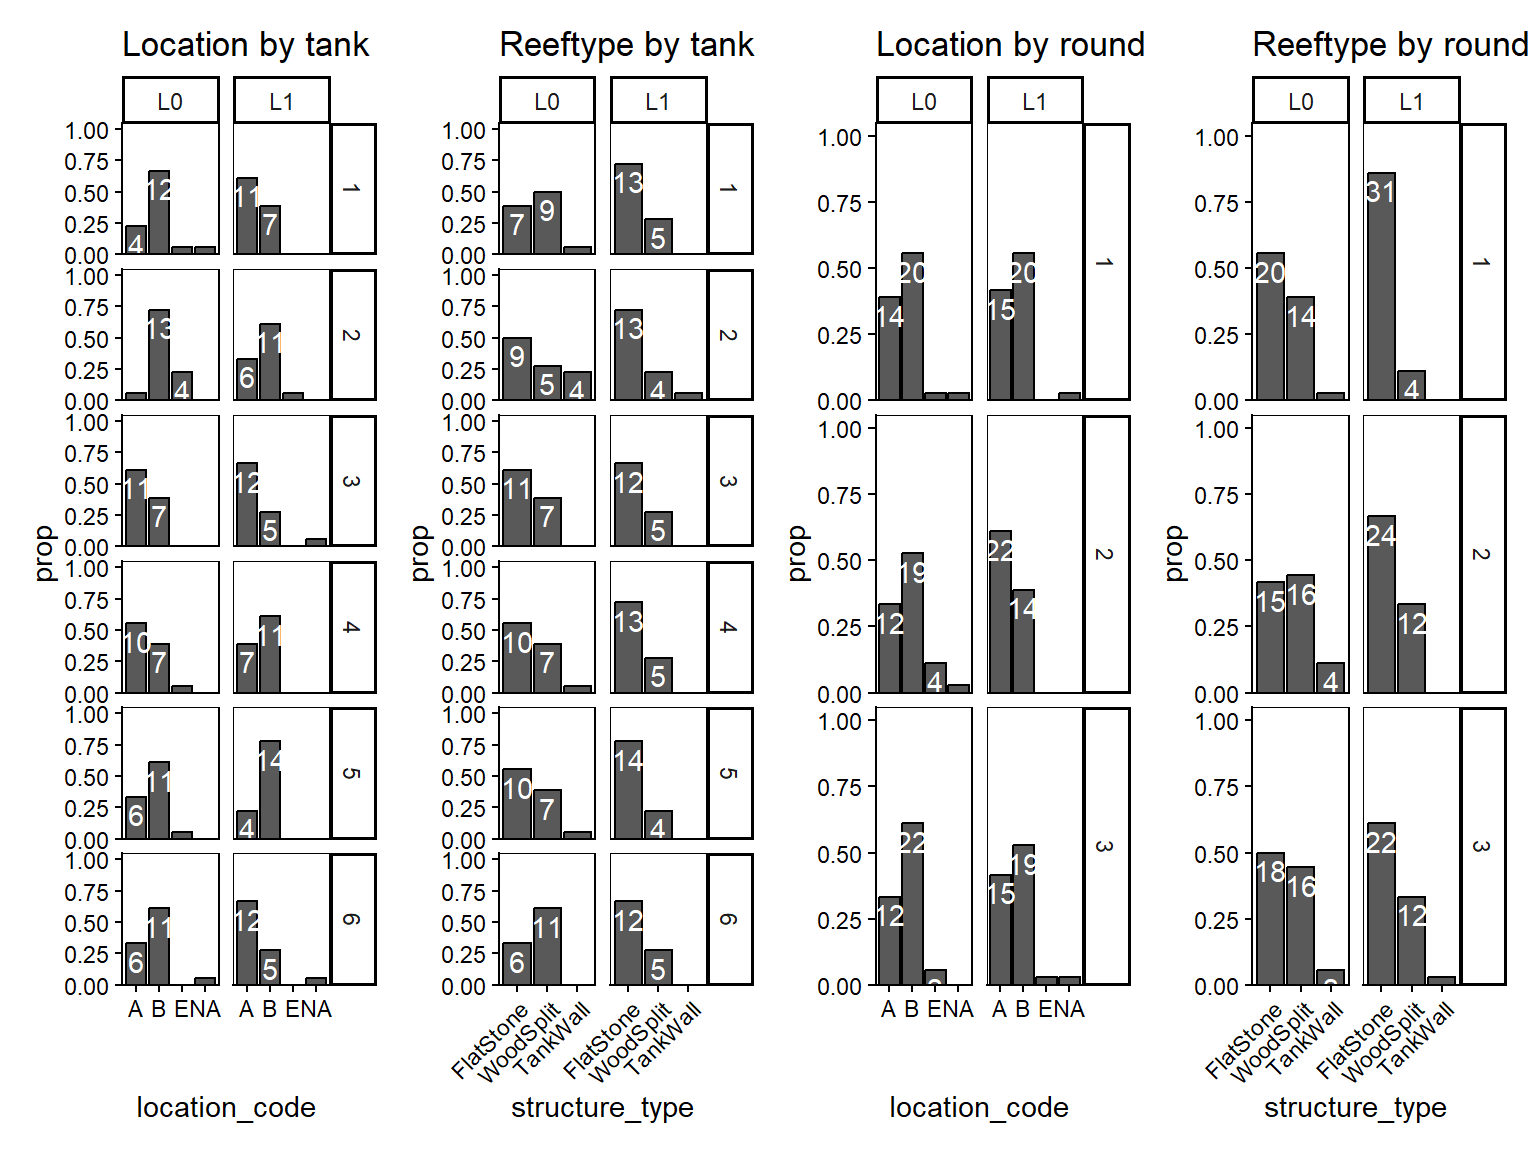

In [ ]:

invisible(capture.output({
  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

# bar plot; uses facet_grid for rows=facetvar, cols=stage
  mk_bar <- function(df, xvar, facetvar, title, structure = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title)+
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (structure) {
      p <- p +
        scale_x_discrete(limits = STRUCTURE_LEVELS3, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }
  # data
  exp3_loc    <- mk_props(df_exp3_woodstone_long, location_code, tank)
  exp3_round  <- mk_props(df_exp3_woodstone_long, location_code, round)
  exp3_loc3   <- mk_props(df_exp3_woodstone_long, structure_type,     tank)
  exp3_round3 <- mk_props(df_exp3_woodstone_long, structure_type,     round)
  # plots
  p_exp3_loc    <- mk_bar(exp3_loc,   location_code, tank,  "Location by tank")
  p_exp3_round  <- mk_bar(exp3_round, location_code, round, "Location by round")
  p_exp3_loc3   <- mk_bar(exp3_loc3,  structure_type,     tank,  "Reeftype by tank",  structure = TRUE)
  p_exp3_round3 <- mk_bar(exp3_round3,structure_type,     round, "Reeftype by round", structure = TRUE)

loc_round_plots_exp3 <<- p_exp3_loc + p_exp3_loc3 + p_exp3_round + p_exp3_round3 +
    patchwork::plot_layout(ncol = 4)
}))

ggsave(loc_round_plots_exp3, file = file.path(out_dir, "fig-exp3-tank-round.png"), width = 10, height = 7, dpi = 300)


# Exp 4 Bricks

## Exp 4 Statistic

In [ ]:

# RQ 1: Does overall structure preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does sex affect structure preference? (brms categorical)

df4 <- df_exp4_brick_long %>%
  mutate(
    structure_type      = factor(structure_type),
    stage          = factor(stage, levels = c("L1")),
    sex            = factor(sex),
    size_class     = factor(size_class, levels = c("S", "M", "L")),
    location_code  = factor(location_code),
    tank           = factor(tank),
    round          = factor(round),
    group_id       = factor(group_id),
    koura_id       = factor(koura_id)) %>%
  filter(!is.na(structure_type))

size_stats4 <- df4 %>%
  distinct(koura_id, sex, size_mm1, weight_g1) %>%
  group_by(sex) %>%
  summarise(mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
    sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
    min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
    max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
    mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
    sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
    min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
    max_wt   = round(max(weight_g1,  na.rm = TRUE), 1),
    .groups  = "drop") %>%
  bind_rows(df4 %>%
      distinct(koura_id, size_mm1, weight_g1) %>%
      summarise(sex = "Total",
        mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
        sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
        min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
        max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
        mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
        sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
        min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
        max_wt   = round(max(weight_g1,  na.rm = TRUE), 1)))

pct_wall4 <- round(sum(df4$structure_type == "TankWall" & df4$stage == "L1") / sum(df4$stage == "L1") * 100)

# RQ1 — Overall structure preference at group level
df4_grp <- df4 %>%
  count(group_id, round, structure_type) %>%
  filter(structure_type != "TankWall") %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

# Test whether proportion at each structure type differs from uniform (.5)
wilcox_bart  <- wilcox.test(df4_grp$prop[df4_grp$structure_type == "BrickConcrete"],  mu = .5, exact = FALSE)
wilcox_bwood  <- wilcox.test(df4_grp$prop[df4_grp$structure_type == "BrickWood"],  mu = .5, exact = FALSE)


p_wilcox4_adjusted <- p.adjust(c(p_wilcox4_bart = wilcox_bart$p.value, p_wilcox4_bwood = wilcox_bwood$p.value), method = "bonferroni")

p_wilcox4_adjusted


 p_wilcox4_bart p_wilcox4_bwood 
      0.2731588       0.2731588 

[1] 0.1365794

  sum(Value)
1          0

 Family: categorical 
  Links: muBrickWood = logit; muTankWall = logit 
Formula: reef_type ~ sex + (1 | group_id/koura_id) + (1 | round) 
   Data: df4 %>% filter(stage == "L1") (Number of observations: 160) 
  Draws: 4 chains, each with iter = 4000; warmup = 2000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~group_id (Number of levels: 4) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muBrickWood_Intercept)     0.42      0.48     0.01     1.72 1.00     3056
sd(muTankWall_Intercept)      2.88      2.10     0.34     8.39 1.00     2977
                          Tail_ESS
sd(muBrickWood_Intercept)     3509
sd(muTankWall_Intercept)      2464

~group_id:koura_id (Number of levels: 40) 
                          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(muBrickWood_Intercept)     0.47      0.31     0.02     1.14 1.00     1986
sd(muTankWall_Intercept)      2.00      0.95     0.42     4.18 1.00     2274
            

$group_id
$group_id$sd
                       Estimate Est.Error       Q2.5    Q97.5
muBrickWood_Intercept 0.4249234  0.483183 0.01244239 1.715125
muTankWall_Intercept  2.8783310  2.104532 0.34191282 8.386438


$`group_id:koura_id`
$`group_id:koura_id`$sd
                       Estimate Est.Error       Q2.5    Q97.5
muBrickWood_Intercept 0.4678771 0.3069960 0.02189929 1.138449
muTankWall_Intercept  2.0011497 0.9454752 0.41862111 4.178115


$round
$round$sd
                       Estimate Est.Error       Q2.5    Q97.5
muBrickWood_Intercept 0.3288562 0.3840231 0.01020109 1.321490
muTankWall_Intercept  1.5681425 1.0959690 0.16208062 4.324139

[1] 0.638

## Exp 4 Table

In [ ]:

fixef(m_exp4_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)


  Parameter                  Mean     SD     2.5%   97.5%
  ----------------------- ------- ------ -------- -------
  muBrickWood_Intercept      0.21   0.52    -0.80    1.26
  muTankWall_Intercept      -1.44   2.66    -5.93    4.72
  muBrickWood_sexM          -0.18   0.54    -1.29    0.85
  muTankWall_sexM           -2.43   3.57   -11.52    2.38


## Exp 4 Figure

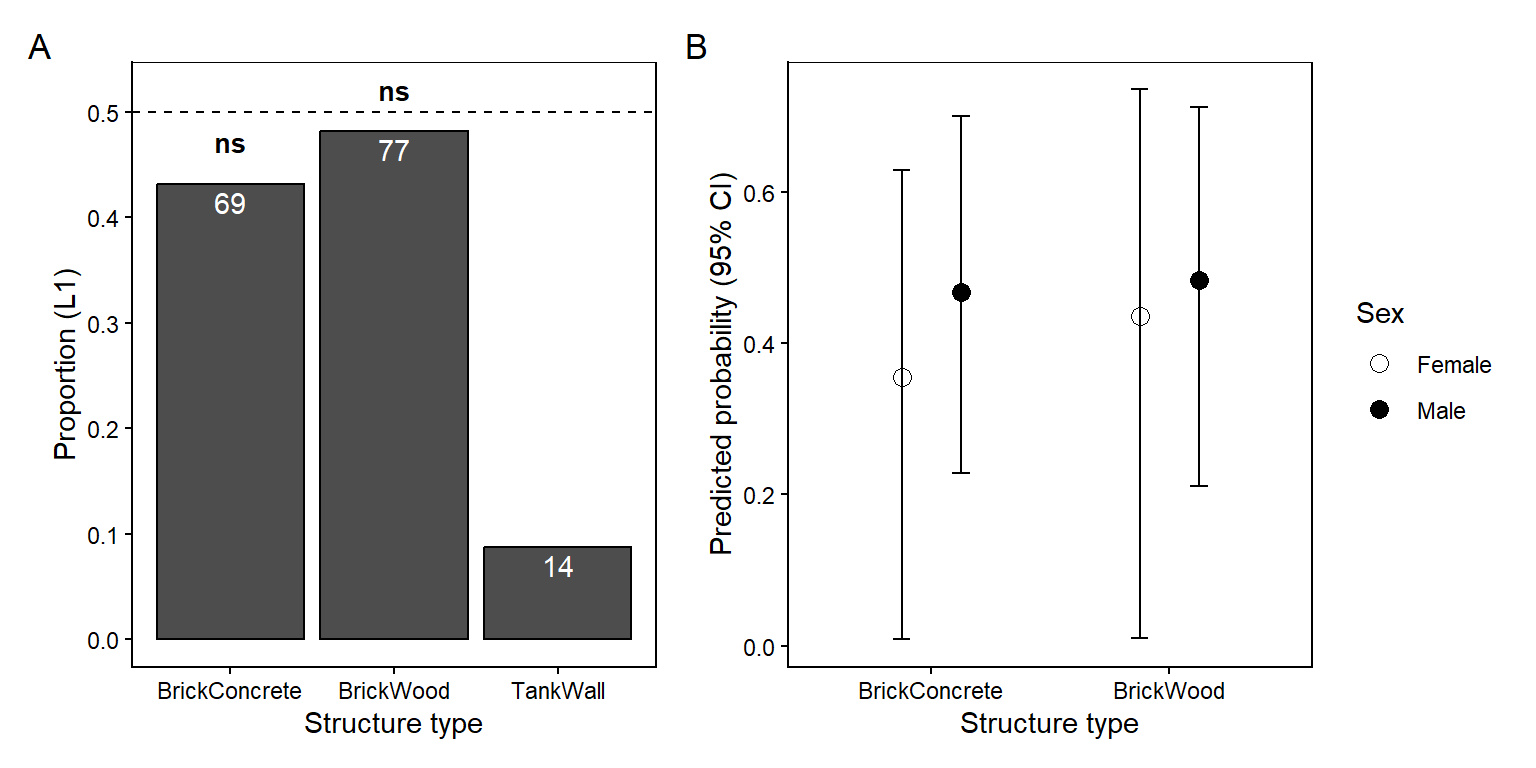

In [ ]:

exp4_combined <- df_exp4_brick_long %>%
  filter(stage == "L1", !is.na(structure_type)) %>%
  count(structure_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_structure4()

ann_wilcox4 <- data.frame(structure_type = c("BrickConcrete", "BrickWood"),label = c(sig_label(p_wilcox4_adjusted["p_wilcox4_bart"]), sig_label(p_wilcox4_adjusted["p_wilcox4_bwood"]))) %>%
  mutate(structure_type = factor(structure_type, levels = STRUCTURE_LEVELS4)) %>%
  left_join(exp4_combined %>% select(structure_type, prop), by = "structure_type") %>%
  mutate(y = prop + 0.04, label = case_when( structure_type %in% c("BrickConcrete", "BrickWood") & label != "ns" ~ paste0(label, "↑"), TRUE ~ label))

Exp4_combined_p <- exp4_combined %>%
  relevel_structure4() %>%
  ggplot(aes(structure_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = .5, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox4, aes(x = structure_type, y = y, label = label), size = 3.5, fontface = "bold") +
  #scale_y_continuous(limits = c(0, 0.75)) +
  labs(x = "Structure type", y = "Proportion (L1)", tag = "A")

ce4_p <- pp_summary4 %>%
  filter(structure_type != "TankWall") %>%
  relevel_structure4() %>%
  ggplot(aes(structure_type, mean_prob, shape = sex, group = sex)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 3, position = position_dodge(0.5)) +
  scale_shape_manual(values = sex_shape_map, labels = c(F = "Female", M = "Male")) +
  labs(x = "Structure type", y = "Predicted probability (95% CI)", shape = "Sex", tag = "B")

Exp4_p <- Exp4_combined_p | ce4_p

ggsave(Exp4_p, file = file.path(out_dir, "fig-exp4.png"), width = 8, height = 4, dpi = 300)

Exp4_p


## Exp 4 II

# A tibble: 20 × 5
   group_id size_class sex   structure_type     n
      <dbl> <chr>      <chr> <fct>          <int>
 1        7 L          F     BrickConcrete      2
 2        7 L          F     BrickWood          2
 3        7 M          F     BrickConcrete     15
 4        7 M          F     BrickWood          9
 5        7 M          F     TankWall           4
 6        7 S          F     BrickWood          8
 7        8 M          F     BrickConcrete     11
 8        8 M          F     BrickWood         15
 9        8 M          F     TankWall           2
10        8 M          M     BrickConcrete      2
11        8 M          M     BrickWood          2
12        8 S          F     BrickConcrete      2
13        8 S          F     BrickWood          2
14        8 S          M     BrickConcrete      2
15        8 S          M     BrickWood          2
16        9 M          M     BrickConcrete     15
17        9 M          M     BrickWood         17
18        9 M          M     Ta

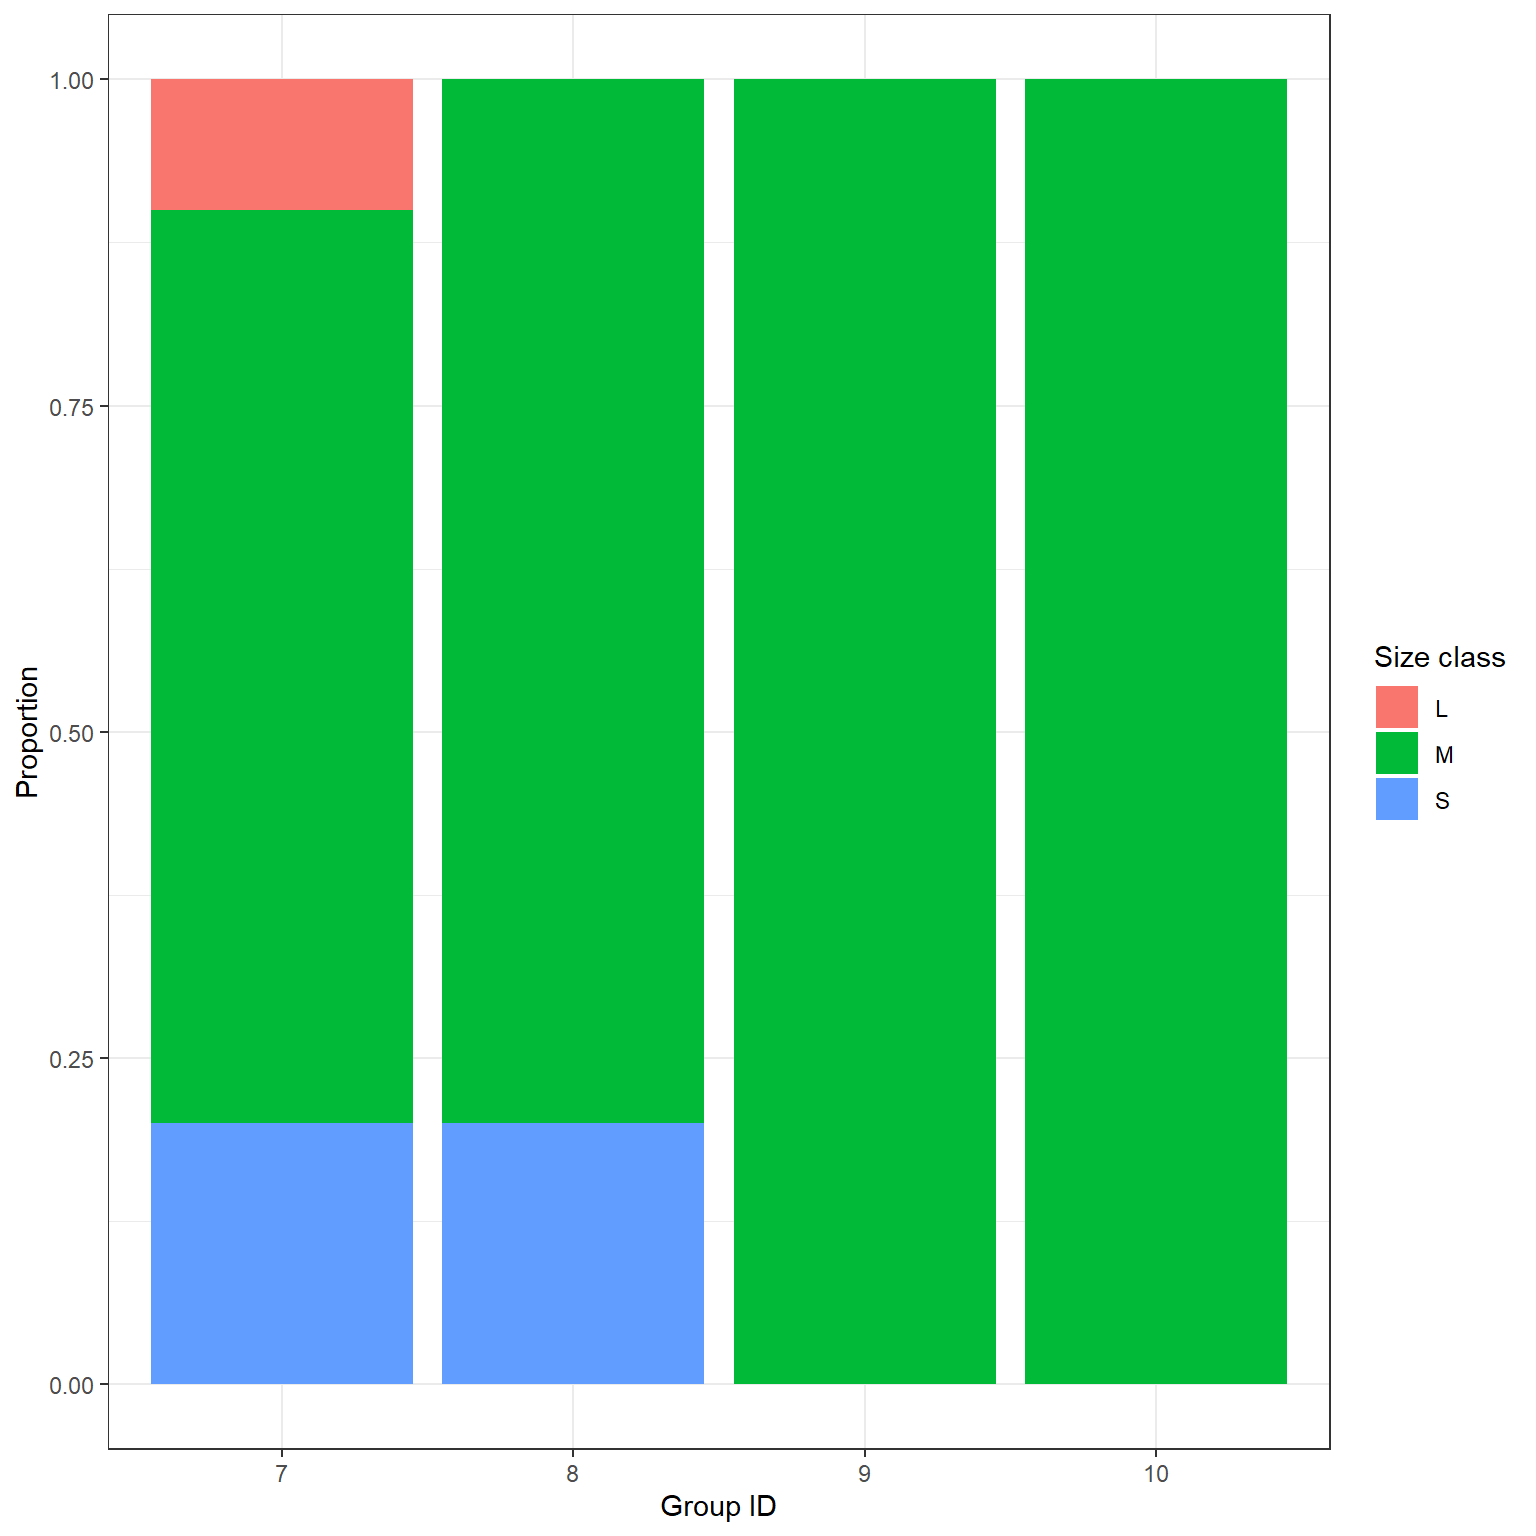

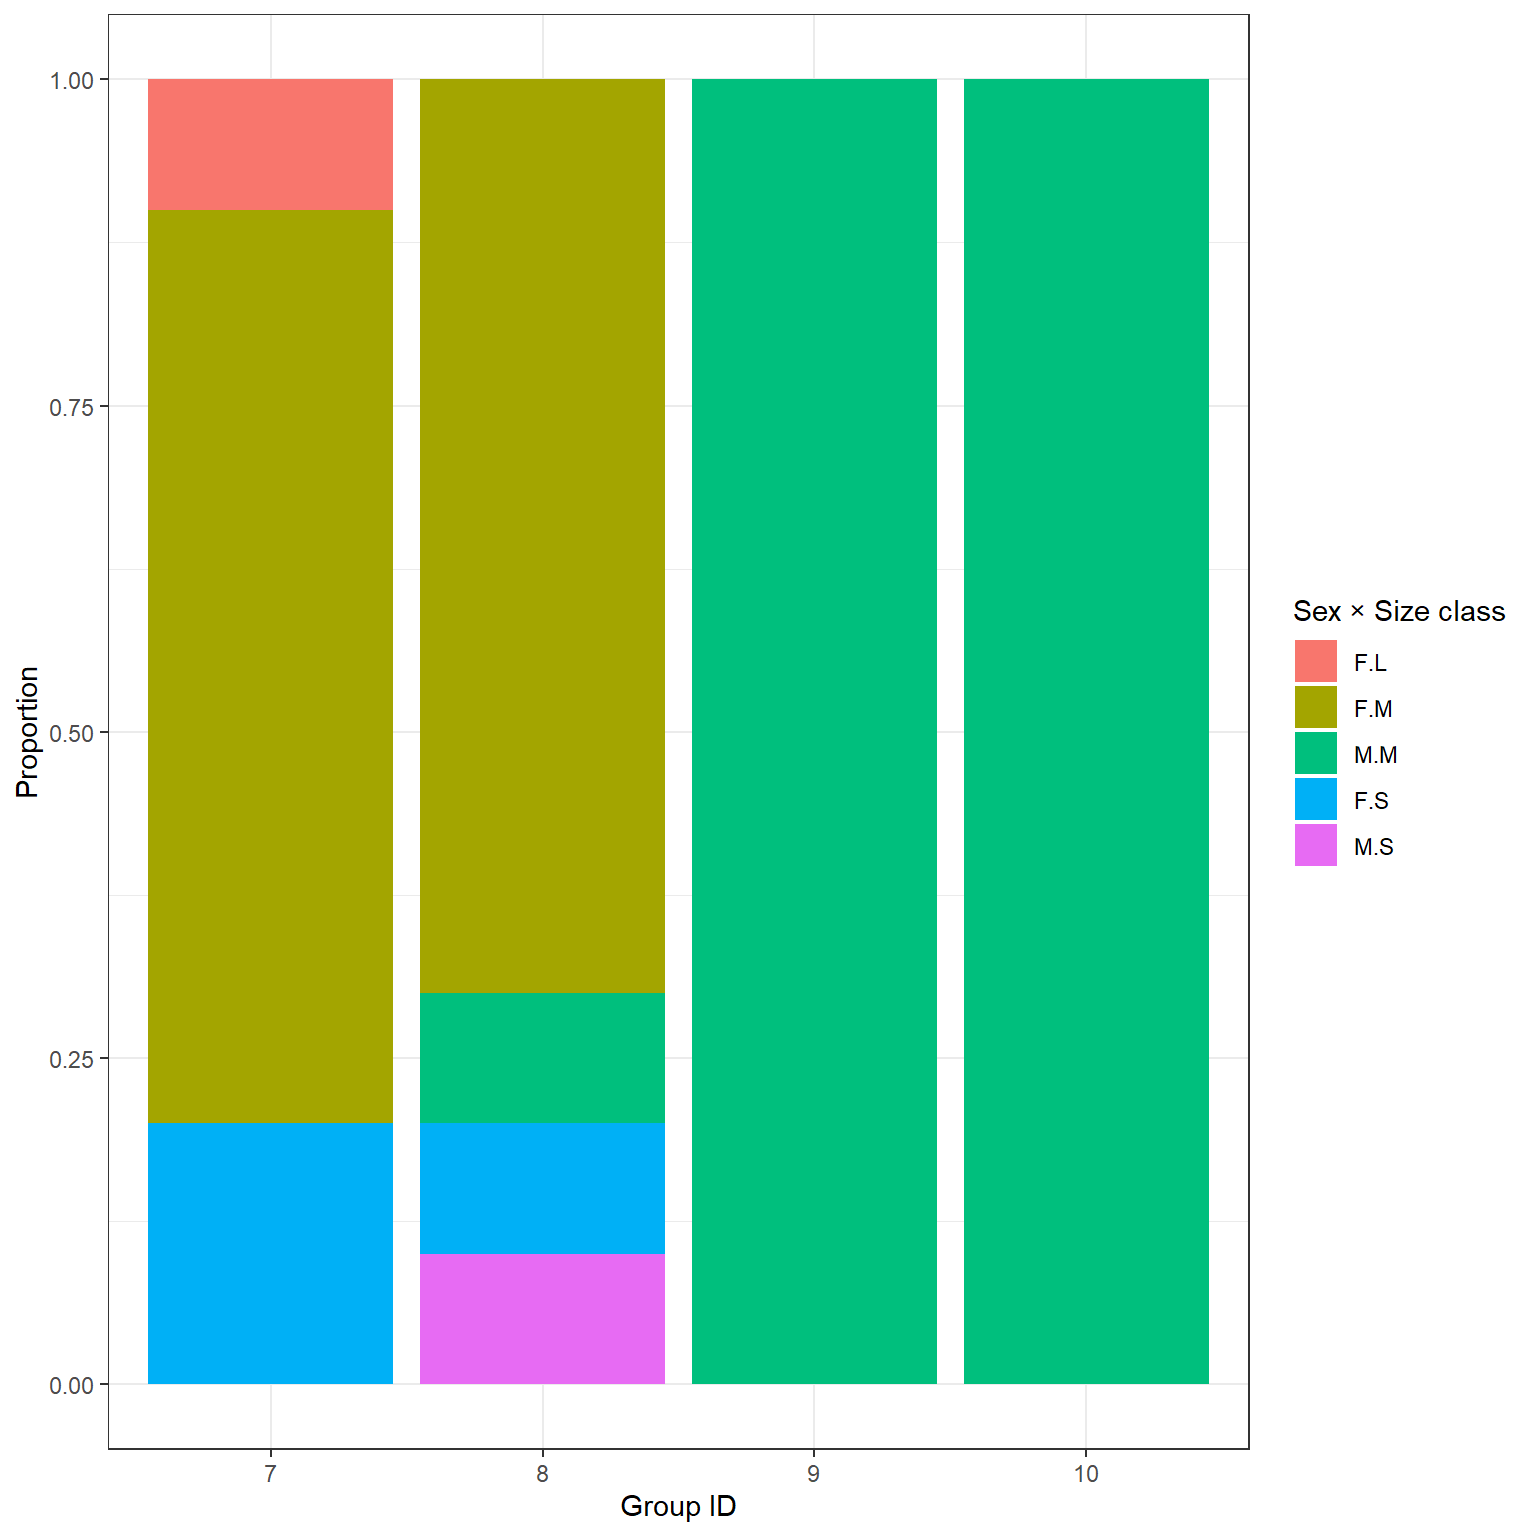

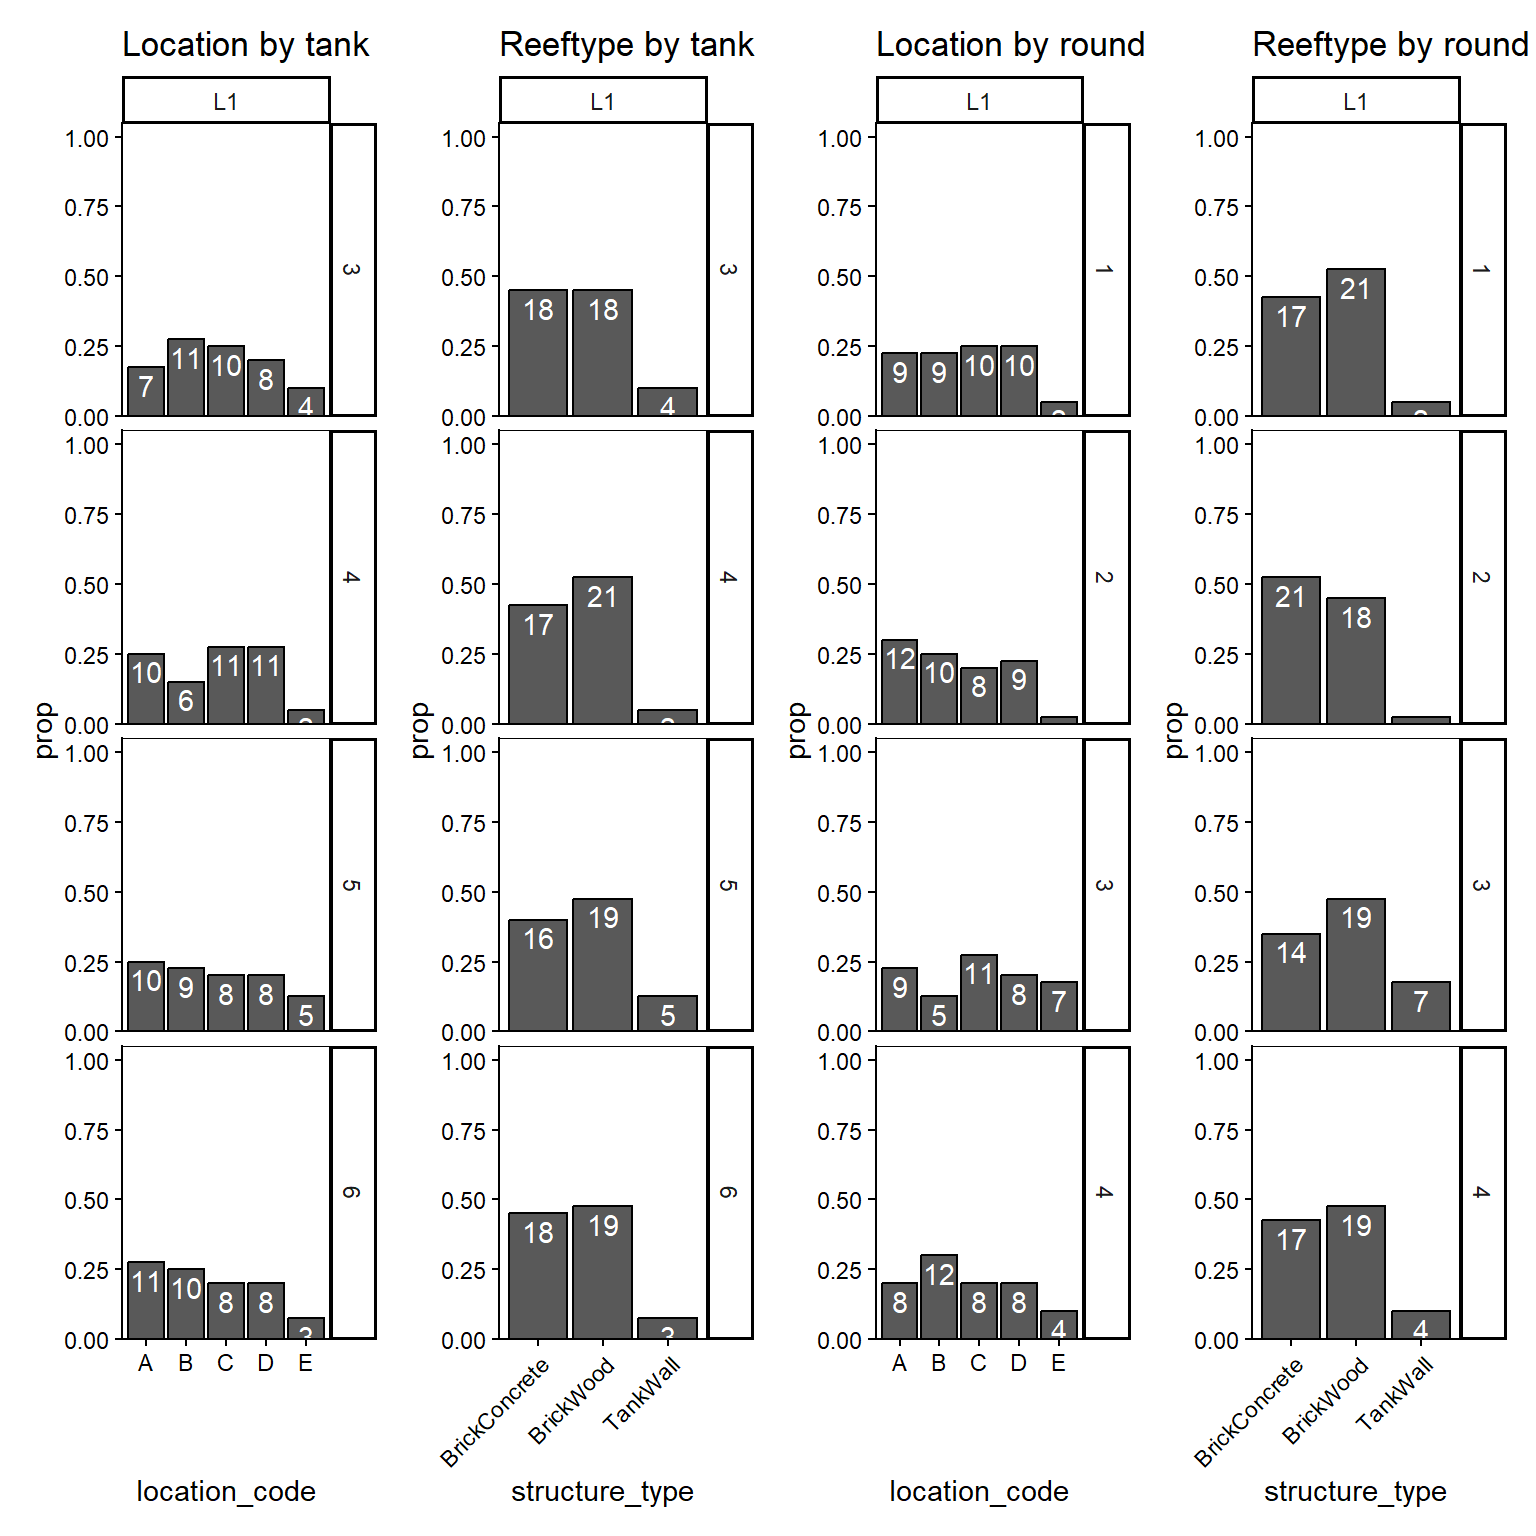

In [ ]:

df_exp4_brick_long %>%
  group_by(group_id, size_class, sex, structure_type) %>%
  summarise(n = n(), .groups = "drop") %>%
  arrange(group_id, size_class)


# Combine figure for presentation

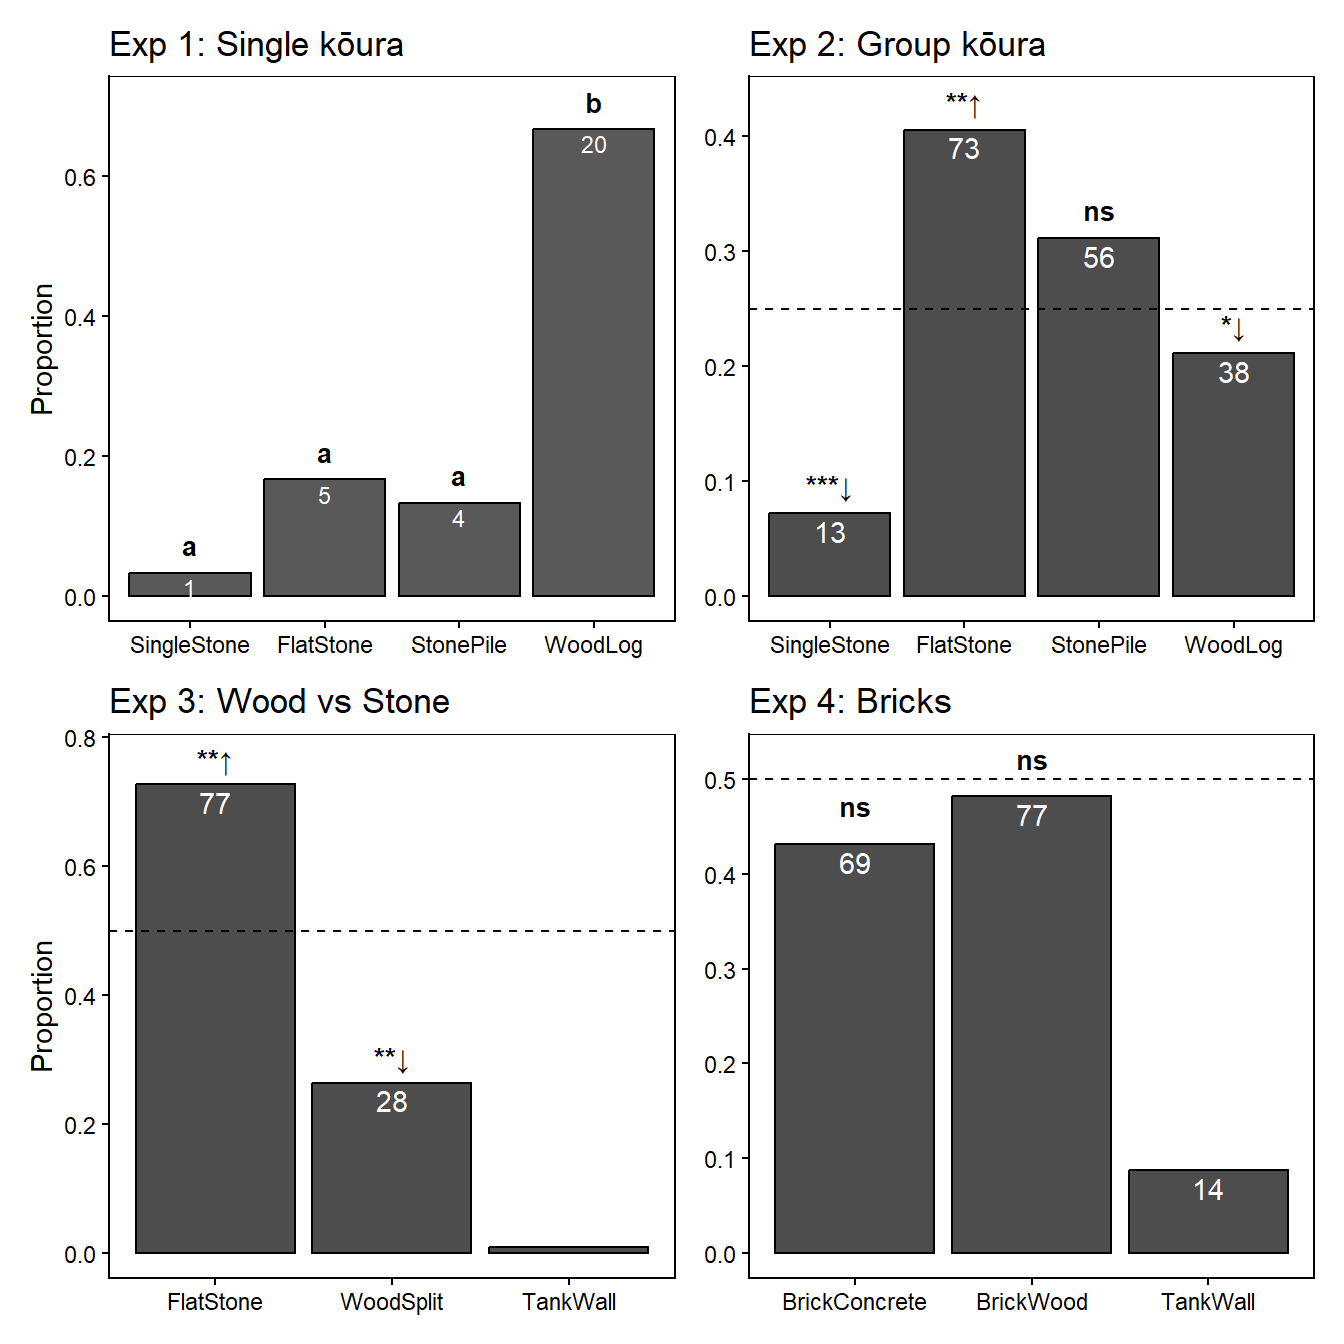

In [ ]:

p1 <- exp1_p_combined + labs(x = NULL, y = "Proportion", title = "Exp 1: Single kōura")
p2 <- Exp2_combined_p + labs(x = NULL, y = NULL, title = "Exp 2: Group kōura", tag = NULL)
p3 <- Exp3_combined_p + labs(x = NULL, y = "Proportion", title = "Exp 3: Wood vs Stone", tag = NULL)
p4 <- Exp4_combined_p + labs(x = NULL, y = NULL, title = "Exp 4: Bricks", tag = NULL)

fig_all_presentation <- p1 + p2 + p3 + p4 + plot_layout(nrow = 2)

ggsave(fig_all_presentation, file = file.path(out_dir, "fig-all-presentation.png"), width = 6.5, height = 6.5, dpi = 300)
fig_all_presentation


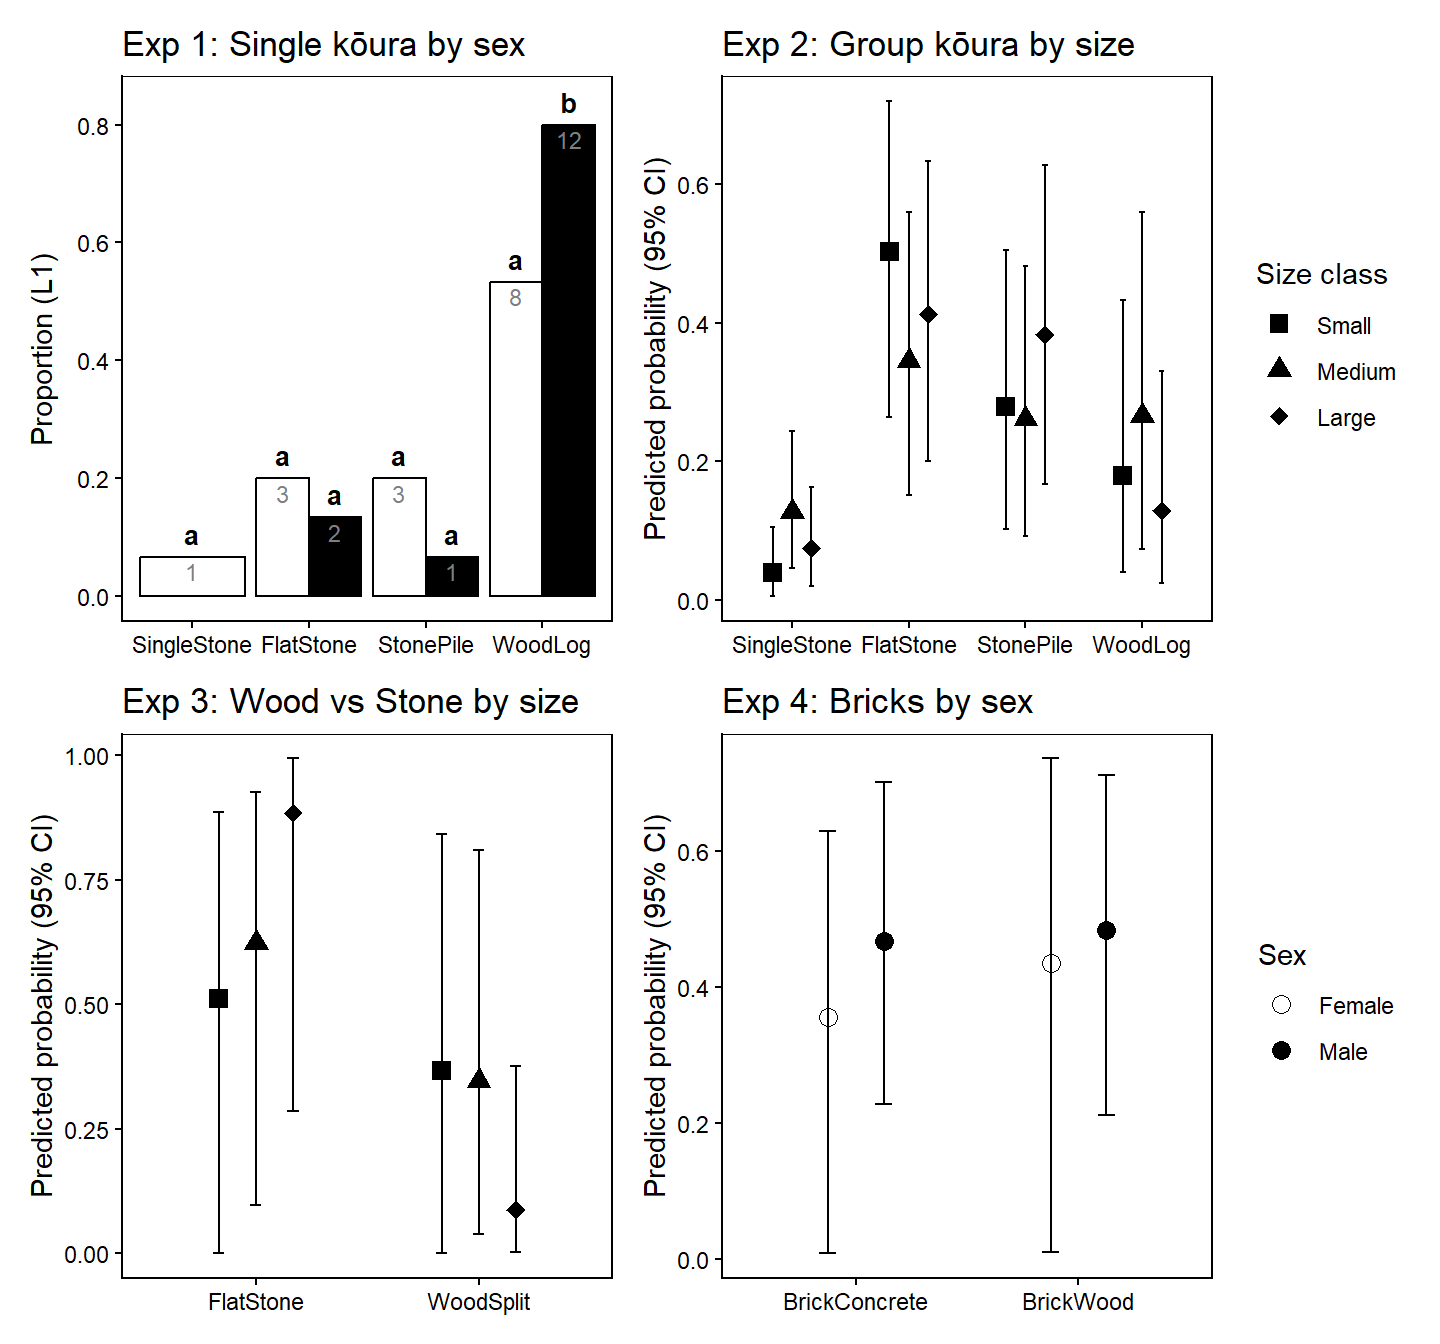

In [ ]:

sex1_p <- exp1_p_sex + labs(x = NULL, y = "Proportion (L1)", title = "Exp 1: Single kōura by sex") + theme(legend.position = "none")
ce2_pp <- ce2_p + labs(x = NULL, y = "Predicted probability (95% CI)", title = "Exp 2: Group kōura by size", tag = NULL)
ce3_pp <- ce3_p + labs(x = NULL, y = "Predicted probability (95% CI)", title = "Exp 3: Wood vs Stone by size", tag = NULL) + theme(legend.position = "none")
ce4_pp <- ce4_p + labs(x = NULL, y = "Predicted probability (95% CI)", title = "Exp 4: Bricks by sex", tag = NULL)

ce_all <- sex1_p + ce2_pp + ce3_pp + ce4_pp + plot_layout(nrow = 2)

ggsave(ce_all, file = file.path(out_dir, "fig-ce-all-presentation.png"), width = 7.5, height = 7, dpi = 300)

ce_all


# Waterquality

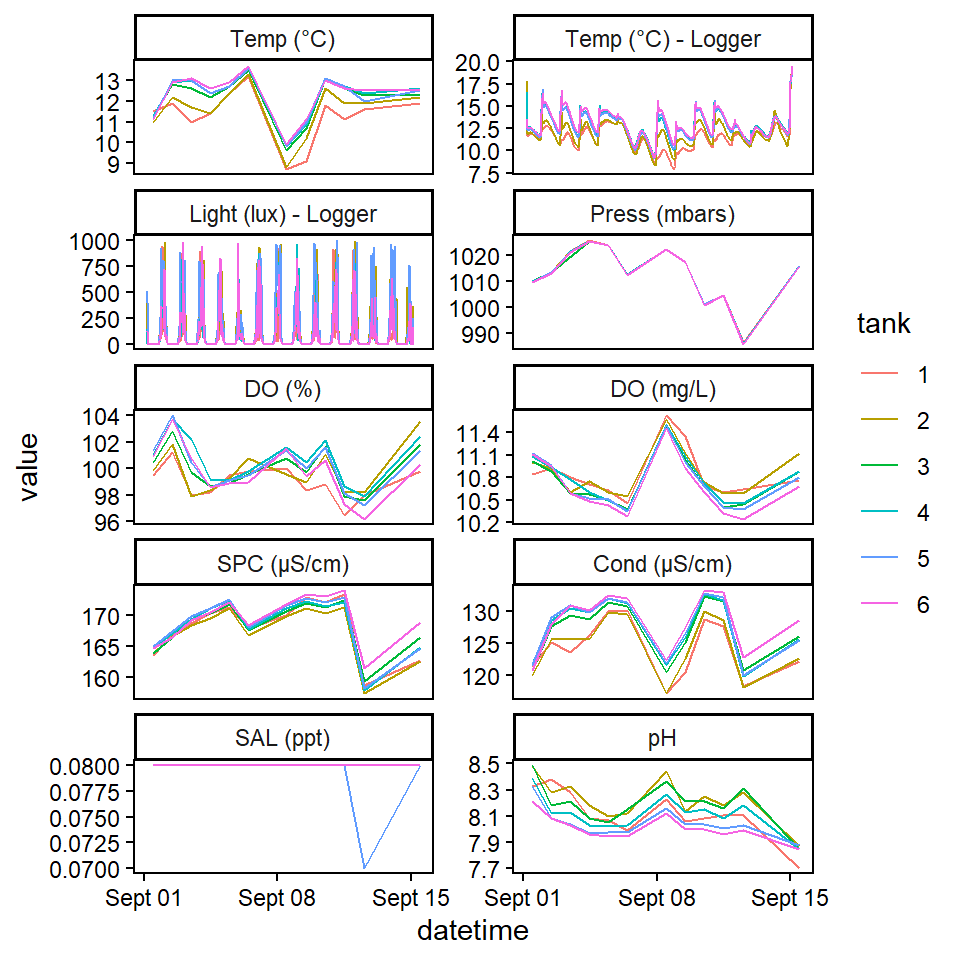

In [ ]:

wq_clean <- df_wq %>%
  mutate(value = suppressWarnings(as.numeric(value)),tank  = factor(tank),param_label = ifelse(is.na(unit) | unit %in% c("", "NA"), parameter_abb, paste(parameter_abb, unit))) %>%
  filter(!is.na(tank_use), !is.na(value),data_time >= as.POSIXct("2025-09-01"),tank_use == "Experiment")

wq_probe <- wq_clean %>%
  transmute(datetime = data_time,tank,param_label,value)

# --- Logger data (df_loggers) -> give unique param_label names ---
wq_logger <- df_loggers %>%
  rename(datetime = data_time) %>%
  mutate(tank     = factor(tank),
    datetime = lubridate::ymd_hms(datetime, tz = "Pacific/Auckland")) %>%
  pivot_longer(c(temperature, light), names_to = "param", values_to = "value") %>%
  mutate(
    param_label = case_when(
      param == "temperature" ~ "Temp (°C) - Logger",
      param == "light"       ~ "Light (lux) - Logger",
      TRUE                   ~ param),
    date  = as.Date(datetime),
    time  = format(datetime, "%H:%M:%S"),
    year  = year(datetime),
    month = month(datetime, label = TRUE),
    day   = day(datetime)) %>%
  filter(
    datetime >= as.POSIXct("2025-09-01", tz = "Pacific/Auckland"),
    (param_label != "Light (lux) - Logger" | value <= 1000),
    (param_label != "Temp (°C) - Logger"   | value <= 20) ) %>%
  transmute(datetime, date, time, year, month, day, tank, param_label, value)

# --- Combine into ONE df, keep labels distinct ---
PARAM_LEVELS <- c("Temp (°C)", "Temp (°C) - Logger","Light (lux) - Logger",
                  "Press (mbars)","DO (%)","DO (mg/L)","SPC (µS/cm)","Cond (µS/cm)","SAL (ppt)","pH")

wq_all <- bind_rows(wq_probe, wq_logger) %>%
  mutate(param_label = factor(param_label, levels = PARAM_LEVELS),tank = factor(tank)) %>%
  tidyr::drop_na(value)

# --- Plot from the single df ---
wq_all_plot <- ggplot(wq_all, aes(datetime, value, color = tank, group = tank)) +
  geom_line() +
  facet_wrap(~ param_label, scales = "free_y", ncol = 2)

wq_all_plot
ggsave(wq_all_plot, file = file.path(out_dir, "fig-wq.png"), width = 5, height = 5, dpi = 300)


# Length-Weight of koura

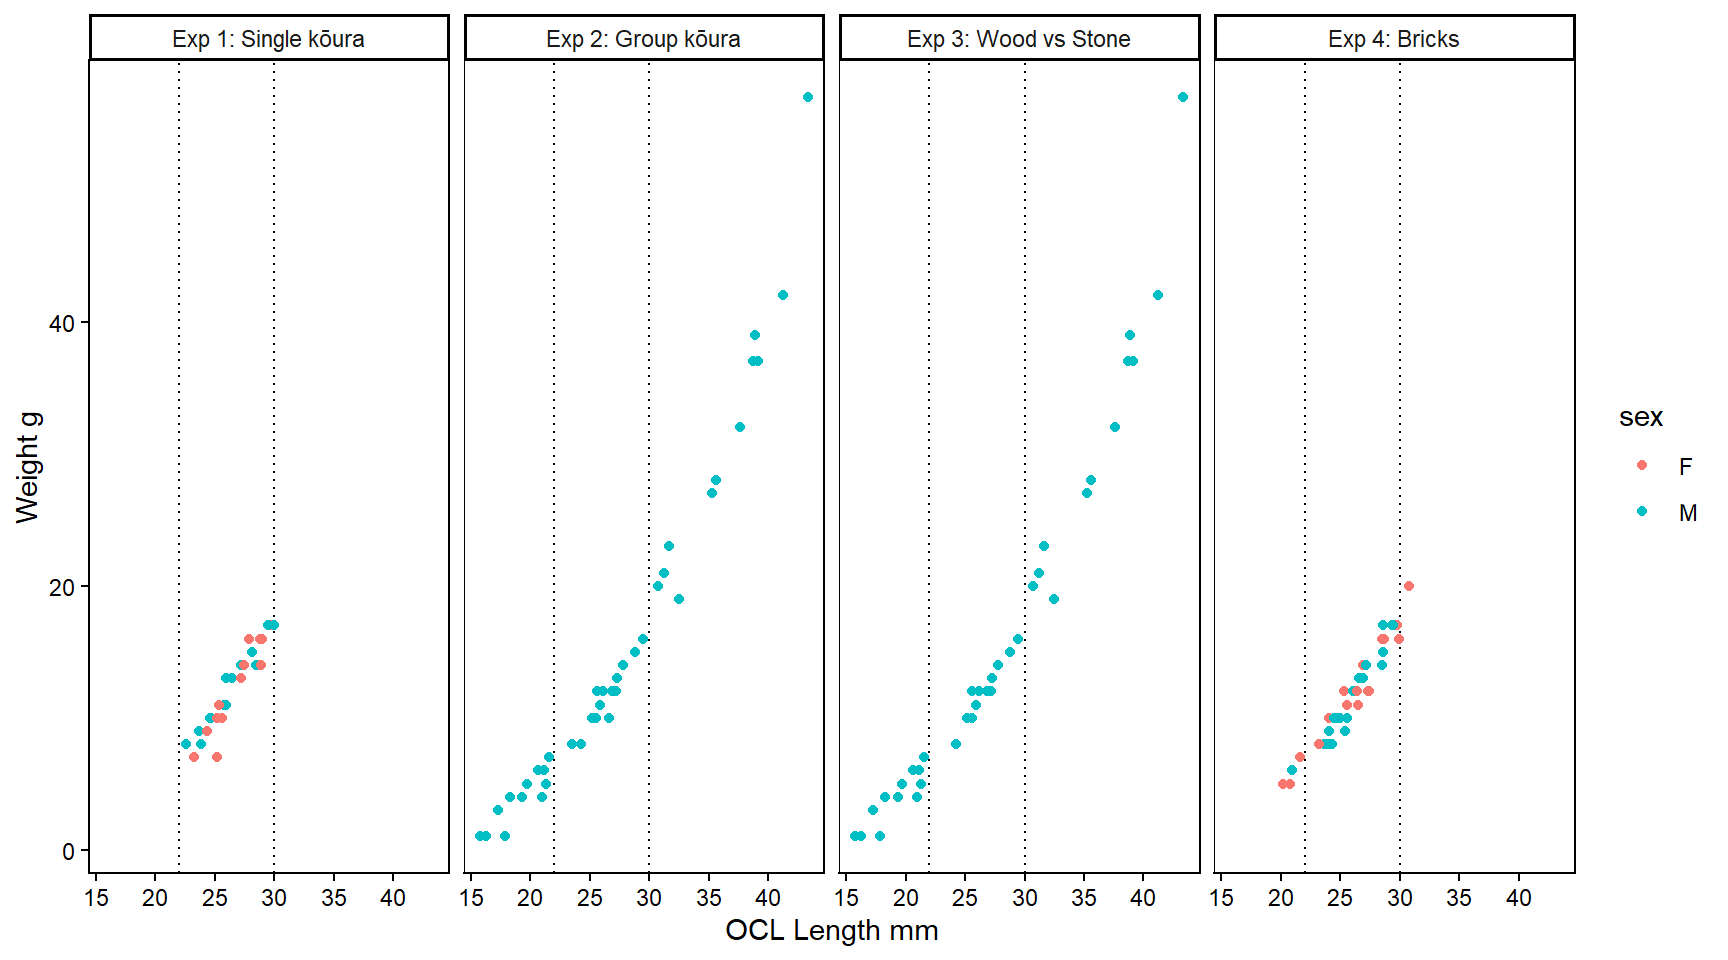

In [ ]:

df_size_weight_all <- dplyr::bind_rows(
  df_exp1_single_raw %>%
    dplyr::transmute(experiment = "Exp 1: Single kōura",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex)), df_exp2_group_raw %>%
    dplyr::transmute(
      experiment = "Exp 2: Group kōura",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex)),df_exp3_woodstone_raw %>%
    dplyr::transmute(
      experiment = "Exp 3: Wood vs Stone",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex)),df_exp4_brick_raw %>%
    dplyr::transmute(
      experiment = "Exp 4: Bricks",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex))) %>%
  dplyr::filter(!is.na(size_mm1), !is.na(weight_g1)) %>%
  dplyr::mutate(experiment = factor(experiment))

p_size_weight <- ggplot2::ggplot(
  df_size_weight_all,
  ggplot2::aes(x = size_mm1, y = weight_g1, colour = sex)) +
  ggplot2::geom_vline(xintercept = 22, linetype = "dotted") +
  ggplot2::geom_vline(xintercept = 30, linetype = "dotted") +
  ggplot2::geom_point()+
  ggplot2::facet_grid(~ experiment)+
  labs(x = "OCL Length mm", y = "Weight g")

p_size_weight


# Session info

In [ ]:
sessionInfo()


R version 4.5.2 (2025-10-31 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26100)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_New Zealand.utf8  LC_CTYPE=English_New Zealand.utf8   
[3] LC_MONETARY=English_New Zealand.utf8 LC_NUMERIC=C                        
[5] LC_TIME=English_New Zealand.utf8    

time zone: Pacific/Auckland
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] writexl_1.5.4       readxl_1.4.5        forcats_1.0.1      
 [4] dplyr_1.2.0         purrr_1.2.1         readr_2.2.0        
 [7] tidyr_1.3.2         tibble_3.3.1        ggplot2_4.0.2      
[10] tidyverse_2.0.0     stringr_1.6.0       lubridate_1.9.5    
[13] janitor_2.2.1       patchwork_1.3.2     multcompView_0.1-11
[16] lme4_1.1-38         Matrix_1.7-4        nnet_7.3-20        
[19] brms_2.23.0         Rcpp_1.1.1          XNomial_1.0.4.1    


```` markdown
---
title: "Analysis Notebook"
format:
  html:
    fig-path: "analysis_files/figure-html/"
    theme:
      light: flatly
      dark: darkly
    code-fold: true
    code-tools: true
    code-summary: "View Code"
    toc: true
    toc-depth: 3
    number-sections: true
fig-width: 8
fig-height: 6

execute:
  freeze: false
  cache: false

---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
#| include: false
packages <- c("emmeans","DescTools", "coin","XNomial","brms","nnet","lme4","multcompView","patchwork","janitor","lubridate","stringr","tidyverse","dplyr","ggplot2","readxl","writexl","readr")

quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

invisible(lapply(packages, quiet_load))

# Set paths
exc_file_dir    <- "data/raw/Mesocosm_experiment.xlsx"
raw_data_dir    <- "data/raw"
der_data_dir    <- "data/derived"
out_dir         <- "outputs"

read_sheet <- function(sheet) {readxl::read_excel(exc_file_dir, sheet = sheet)}
write_out <- function(df, name) {write.csv(df, file.path(der_data_dir, name), row.names = FALSE)}

# Read data
df_koura               <- read_sheet("Koura")
df_setup               <- read_sheet("Tank_setup")
df_exp1_single_raw     <- read_sheet("exp1")
df_exp2_group_raw      <- read_sheet("exp2")
df_exp3_woodstone_raw  <- read_sheet("exp3")
df_exp4_brick_raw      <- read_sheet("exp4")
df_wq                  <- read_sheet("WQ")
df_loggers             <- read_sheet("Loggers")

# Save as csv to derived
write_out(df_koura,              "df_koura.csv")
write_out(df_setup,              "df_setup.csv")
write_out(df_exp1_single_raw,    "df_exp1_single_raw.csv")
write_out(df_exp2_group_raw,     "df_exp2_group_raw.csv")
write_out(df_exp3_woodstone_raw, "df_exp3_woodstone_raw.csv")
write_out(df_exp4_brick_raw,     "df_exp4_brick_raw.csv")
write_out(df_wq,                 "df_wq.csv")
write_out(df_loggers,            "df_loggers.csv")

# set preferred orders
STRUCTURE_LEVELS  <- c("SingleStone","FlatStone","StonePile","WoodLog","TankWall")
STRUCTURE_LEVELS3 <- c("FlatStone","WoodSplit","TankWall")
STRUCTURE_LEVELS4 <- c("BrickConcrete","BrickWood","TankWall")
LOC_LEVELS   <- c("A", "B", "C", "D", "E")
LOC_LEVELS3  <- c("A", "B", "E")

relevel_structure  <- function(df) df %>% mutate(structure_type = factor(as.character(structure_type),levels = STRUCTURE_LEVELS))
relevel_structure3 <- function(df) df %>% mutate(structure_type = factor(as.character(structure_type),levels = STRUCTURE_LEVELS3))
relevel_structure4 <- function(df) df %>% mutate(structure_type = factor(as.character(structure_type),levels = STRUCTURE_LEVELS4))

# Set plot theme
windowsFonts(Arial = windowsFont("Arial"))
base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "Arial", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.5))
theme_set(base_theme_bw)

get_sex <- function(tbl, sex, col) {
  tbl[[col]][tbl$sex == sex]
}

get_size <- function(tbl, class, col) {
  tbl[[col]][tbl$size_class == class]
}

# Build pairwise_gtest
pairwise_gtest <- function(counts) {
  nms   <- names(counts)
  pairs <- combn(nms, 2, simplify = FALSE)
  
  results <- lapply(pairs, function(p) {
    obs_pair <- counts[p]
    exp_pair <- rep(sum(obs_pair) / 2, 2)
    
    G     <- 2 * sum(obs_pair * log(obs_pair / exp_pair), na.rm = TRUE)
    p_val <- pchisq(G, df = 1, lower.tail = FALSE)
    
    data.frame(
      pair  = paste(p, collapse = " vs "),
      G     = round(G, 3),
      p_raw = round(p_val, 4)
    )
  })
  
  out       <- do.call(rbind, results)
  out$p_adj <- round(p.adjust(out$p_raw, method = "bonferroni"), 4)
  out
}

# Function to convert pairwise G-test results to CLD letters
gtest_to_cld <- function(pgtest_result) {
    pvals <- setNames(
    pgtest_result$p_adj,
    gsub(" vs ", "-", pgtest_result$pair))
  multcompView::multcompLetters(pvals)$Letters
}

# Format of p values in text
format_pval <- function(p) {
  if (p < 0.001) {
    return("<0.001")
  } else {
    return(format(round(p, 3), nsmall = 3))
  }
}

sig_label <- function(p) {
  case_when(
    p < 0.001 ~ "***",
    p < 0.01  ~ "**",
    p < 0.05  ~ "*",
    p < 0.1   ~ ".",
    TRUE      ~ "ns"
  )
}

get_brms <- function(model, param, col = "Estimate") {
  tbl <- fixef(model) %>% as.data.frame() %>% rownames_to_column("parameter")
  round(tbl[[col]][tbl$parameter == param], 2)
}

format_brms <- function(model, param, post_prob = NULL) {
  b    <- get_brms(model, param)
  low  <- get_brms(model, param, "Q2.5")
  high <- get_brms(model, param, "Q97.5")
  base <- paste0("(\u03b2 = ", b, ", 95% CI: ", low, " to ", high)
  if (!is.null(post_prob)) {
    pp_label <- ifelse(round(post_prob, 2) >= 1, "> 0.99", as.character(round(post_prob, 2)))
    paste0(base, "; posterior probability = ", pp_label, ")")
  } else paste0(base, ")")
}

size_shape_map <- c(S = 15, M = 17, L = 18) 
sex_shape_map  <- c(F = 1, M = 16)

```


# Build DF's into long format
quarto-executable-code-5450563D

```r
#| label: build_dfs

df_exp1_single_long <- df_exp1_single_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = matches("_(l0|l1)$"),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS),
    structure_type     = factor(structure, levels = STRUCTURE_LEVELS)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, size_mm1, weight_g1, date, stage, t_leave_s, t_l0_s, location_code, structure_type,legs1, claws1, antenna1, size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp1_single_long, "df_exp1_single_long.csv")

# EXP 2 – Group structure (long)
df_exp2_group_long <- df_exp2_group_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = c(location_l0, location_l1,
      structure_l0, structure_l1,legs_l0, claws_l0, antenna_l0,legs_l1, claws_l1, antenna_l1), names_to = c(".value", "stage"), names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage          = toupper(stage),
    location_code  = factor(toupper(location), levels = LOC_LEVELS),
    structure_type      = factor(structure, levels = STRUCTURE_LEVELS),
    size_mm_stage  = if_else(stage == "L0", size_mm1, size_mm2, NA_real_),
    weight_g_stage = if_else(stage == "L0", weight_g1, weight_g2, NA_real_)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date,stage, t_leave_s, t_l0_s, location_code, structure_type,legs, claws, antenna, size_mm_stage, weight_g_stage,size_mm1, weight_g1, legs1, claws1, antenna1,size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp2_group_long, "df_exp2_group_long.csv")


# EXP 3 – Stone / wood (long)
df_exp3_woodstone_long <- df_exp3_woodstone_raw %>%
  mutate(location_l0 = l0, location_l1 = l1) %>%
  pivot_longer(cols = c(location_l0, location_l1, structure_l0, structure_l1),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS3),
    structure_type     = factor(structure, levels = STRUCTURE_LEVELS3)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date, stage, location_code, structure_type, size_mm1, weight_g1, legs1, claws1, antenna1, size_mm2, weight_g2, legs2, claws2, antenna2, notes_exp, notes_koura)

write_out(df_exp3_woodstone_long, "df_exp3_woodstone_long.csv")


# EXP 4 – Bricks (long)
df_exp4_brick_long <- df_exp4_brick_raw %>%
  mutate(location_l1 = l1) %>%
  pivot_longer(cols = c(location_l1, structure_l1),
    names_to = c(".value", "stage"),
    names_pattern = "^(.*)_(l[01])$") %>%
  mutate(stage         = toupper(stage),
    location_code = factor(toupper(location), levels = LOC_LEVELS),
    structure_type     = factor(structure, levels = STRUCTURE_LEVELS4)) %>%
  select(tank, round, group_id, koura_id, size_class, sex, date, stage, location_code, structure_type,size_mm1, weight_g1, legs1, claws1, antenna1,size_mm2, weight_g2, legs2, claws2, antenna2,notes_exp, notes_koura)

write_out(df_exp4_brick_long, "df_exp4_brick_long.csv")
```

# Exp 1 Single koura
## Exp 1 Statistic
quarto-executable-code-5450563D

```r
#| label: stats-exp1
#| tbl-cap: "Exp 1 statistical results"

# RQ 1: Is there a statistical difference between structure type in L1?
# RQ 2: Is there a preference within each sex?
# RQ 3: Does structure type differ between sex?
# RQ 4: Did structure type use shift directionally between L0 and L1?

df1 <- df_exp1_single_long %>%
  mutate(
    structure_type     = factor(structure_type),
    stage         = factor(stage, levels = c("L0", "L1")),
    sex           = factor(sex),
    size_class    = factor(size_class),
    location_code = factor(location_code),
    tank          = factor(tank),
    round         = factor(round),
    koura_id      = factor(koura_id),
    size_mm1      = as.numeric(size_mm1),
    weight_g1     = as.numeric(weight_g1)) %>%
  filter(!is.na(structure_type))

size_stats1 <- df1 %>%
  distinct(koura_id, sex, size_mm1, weight_g1) %>%
  group_by(sex) %>%
  summarise(mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
    sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
    min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
    max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
    mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
    sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
    min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
    max_wt   = round(max(weight_g1,  na.rm = TRUE), 1),
    .groups  = "drop") %>%
  bind_rows(df1 %>%
      distinct(koura_id, size_mm1, weight_g1) %>%
      summarise(sex = "Total",
        mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
        sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
        min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
        max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
        mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
        sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
        min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
        max_wt   = round(max(weight_g1,  na.rm = TRUE), 1)))


df1_L1 <- df1 %>% filter(stage == "L1" , structure_type != "TankWall") %>%
  mutate(structure_type = droplevels(structure_type))

pct_wood_overall <- round(mean(df1_L1$structure_type == "WoodLog") * 100)
pct_wood_male    <- round(mean(df1_L1$structure_type[df1_L1$sex == "M"] == "WoodLog") * 100)
pct_wood_female  <- round(mean(df1_L1$structure_type[df1_L1$sex == "F"] == "WoodLog") * 100)
pct_wall1 <- round(sum(df1$structure_type == "TankWall" & df1$stage == "L1") / sum(df1$stage == "L1") * 100)

# RQ1 — structure type preference at L1
tab1_L1 <- table(df1_L1$structure_type)
tab1_L1_nz <- tab1_L1[tab1_L1 > 0]

xmulti1 <- XNomial::xmulti(obs  = as.numeric(tab1_L1_nz), expr = rep(sum(tab1_L1_nz) / length(tab1_L1_nz), length(tab1_L1_nz)))
p_xmulti1 <- xmulti1$pLLR

# Post-hoc pairwise G-tests
pgtest1 <- pairwise_gtest(tab1_L1_nz)
p_single_vs_flat1 <- pgtest1$p_adj[pgtest1$pair == "SingleStone vs FlatStone"]
p_single_vs_pile1 <- pgtest1$p_adj[pgtest1$pair == "SingleStone vs StonePile"]
p_single_vs_wood1 <- pgtest1$p_adj[pgtest1$pair == "SingleStone vs WoodLog"]
p_flat_vs_pile1   <- pgtest1$p_adj[pgtest1$pair == "FlatStone vs StonePile"]
p_flat_vs_wood1   <- pgtest1$p_adj[pgtest1$pair == "FlatStone vs WoodLog"]
p_pile_vs_wood1   <- pgtest1$p_adj[pgtest1$pair == "StonePile vs WoodLog"]

# Generate CLD letters for each panel
cld_combined1 <- data.frame(
  stage      = "L1",
  panel      = "Combined",
  structure_type  = names(gtest_to_cld(pgtest1)),
  cld_letter = unname(gtest_to_cld(pgtest1)))

# RQ2 — Sex difference in structure preference at L1
tab1_sex     <- table(df1_L1$structure_type, df1_L1$sex)
fisher1      <- fisher.test(tab1_sex, simulate.p.value = TRUE, B = 9999)
p_fisher1    <- fisher1$p.value

# RQ3 — Preference within each sex
structure_levels <- names(tab1_L1_nz)

xmulti1_female <- XNomial::xmulti(
  obs  = as.numeric(table(df1_L1$structure_type[df1_L1$sex == "F"])),
  expr = rep(1/4, 4))
xmulti1_male <- XNomial::xmulti(
  obs  = as.numeric(table(df1_L1$structure_type[df1_L1$sex == "M"])),
  expr = rep(1/4, 4))

if (xmulti1_female$pLLR < 0.05) {
  pgtest1_female <- pairwise_gtest(table(df1_L1$structure_type[df1_L1$sex == "F"]))
  cld_female1    <- data.frame(stage = "L1", panel = "Female",
    structure_type  = names(gtest_to_cld(pgtest1_female)),
    cld_letter = unname(gtest_to_cld(pgtest1_female)))} else {
  cld_female1 <- data.frame(stage = "L1", panel = "Female",
    structure_type = structure_levels, cld_letter = "a")}

if (xmulti1_male$pLLR < 0.05) {
  pgtest1_male <- pairwise_gtest(table(df1_L1$structure_type[df1_L1$sex == "M"]))
  cld_male1    <- data.frame(stage = "L1", panel = "Male",
    structure_type  = names(gtest_to_cld(pgtest1_male)),
    cld_letter = unname(gtest_to_cld(pgtest1_male)))} else {
  cld_male1 <- data.frame(stage = "L1", panel = "Male",
    structure_type = structure_levels, cld_letter = "a")}

cld_all1 <- bind_rows(cld_combined1, cld_female1, cld_male1)

# RQ4 — Directional shift between L0 and L1
df1_wide     <- df1 %>%
  select(koura_id, stage, structure_type) %>%
  pivot_wider(names_from = stage, values_from = structure_type)

tab1_trans   <- table(L0 = df1_wide$L0, L1 = df1_wide$L1)
symtest1     <- coin::symmetry_test(tab1_trans, distribution = approximate(nresample = 9999))
p_symtest1   <- pvalue(symtest1)
```

## Exp 1 Figure
quarto-executable-code-5450563D

```r
#| label: fig-exp1
#| fig-width: 5
#| fig-height: 4
#| fig-cap: "Proportion of individual kōura (Experiment 1) found at each structure type at final observation (L1), shown separately for female and male kōura. Bars show observed proportions with sample sizes (n) shown in white. Letters above bars indicate significant pairwise differences (G-test, Bonferroni adjusted)."

exp1_structure_combined <- df_exp1_single_long %>%
  filter(stage == "L1") %>%
  count(stage, structure_type, name = "n") %>%
  group_by(stage) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_structure() %>%
  mutate(panel = "Combined")

exp1_structure_letters <- exp1_structure_combined %>%
  relevel_structure() %>%
  filter(stage == "L1") %>%
  left_join(cld_all1, by = c("stage", "panel", "structure_type"))

exp1_p_combined <- exp1_structure_combined %>%
  relevel_structure() %>%
  ggplot(aes(structure_type, prop)) +
  geom_col(color = "black") +
  geom_text(aes(label = n), vjust = 1.3, colour = "white", size = 3) +
  geom_text(data = exp1_structure_letters %>% filter(panel == "Combined"),
    aes(y = prop + 0.04, label = cld_letter), size = 3.5, fontface = "bold") +
  labs(x = "Structure type", y = "Proportion (L1)")



exp1_structure_bysex <- df_exp1_single_long %>%
  filter(stage == "L1") %>%
  count(stage, structure_type, sex, name = "n") %>%
  group_by(stage, sex) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_structure() %>%
  mutate(panel = dplyr::recode(sex, F = "Female", M = "Male")) %>%
  select(-sex)

exp1_structure_letters_sex <- exp1_structure_bysex %>%
  left_join(cld_all1, by = c("stage", "panel", "structure_type"))

exp1_p_sex <- exp1_structure_bysex %>%
  relevel_structure() %>%
  ggplot(aes(structure_type, prop, fill = panel)) +
  geom_col(color = "black", position = position_dodge(0.9)) +
  geom_text(aes(label = n), position = position_dodge(0.9), vjust = 1.3, colour = "grey50", size = 3) +
  geom_text(data = exp1_structure_letters_sex,  aes(y = prop + 0.04, label = cld_letter), position = position_dodge(0.9), size = 3.5, fontface = "bold") +
  scale_fill_manual(values = c(Female = "white", Male = "black"), name = "Sex") +
  labs(x = "Structure type", y = NULL) 

exp1_structure_p <- exp1_p_combined + exp1_p_sex 

ggsave(exp1_p_sex, file = file.path(out_dir, "fig-exp1.png"), width = 5, height = 4, dpi = 300)

exp1_p_sex
```


## Exp 1 II
quarto-executable-code-5450563D

```r
#| label: fig-exp1-tank-round
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

invisible(capture.output({
  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

  # bar plot; rows = facetvar, cols = stage; fixed y-scale across all plots
  mk_bar <- function(df, xvar, facetvar, title, structure = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title) +
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (structure) {
      p <- p +
        scale_x_discrete(limits = STRUCTURE_LEVELS, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }

  # data
  exp1_loc    <- mk_props(df_exp1_single_long, location_code, tank)
  exp1_round  <- mk_props(df_exp1_single_long, location_code, round)
  exp1_loc2   <- mk_props(df_exp1_single_long, structure_type,     tank)
  exp1_round2 <- mk_props(df_exp1_single_long, structure_type,     round)

  # plots
  p_exp1_loc    <- mk_bar(exp1_loc,   location_code, tank,  "Location by tank")
  p_exp1_round  <- mk_bar(exp1_round, location_code, round, "Location by round")
  p_exp1_loc2   <- mk_bar(exp1_loc2,  structure_type,     tank,  "Reeftype by tank",  structure = TRUE)
  p_exp1_round2 <- mk_bar(exp1_round2,structure_type,     round, "Reeftype by round", structure = TRUE)

  loc_round_plots_exp1 <<- p_exp1_loc + p_exp1_loc2 + p_exp1_round + p_exp1_round2 +
    patchwork::plot_layout(ncol = 4)
}))

ggsave(loc_round_plots_exp1, file = file.path(out_dir, "fig-exp1-tank-round.png"), width = 10, height = 7, dpi = 300)

loc_round_plots_exp1

```

## Exp 1 III
quarto-executable-code-5450563D

```r
#| label: fig-exp1-III
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

exp1_pairs <- df_exp1_single_long %>%
  dplyr::filter(stage %in% c("L0","L1")) %>%
  dplyr::select(koura_id, tank, round, size_class, sex, stage,location_code, structure_type, t_leave_s, t_l0_s) %>%
  dplyr::mutate(
    location_code = forcats::fct_drop(factor(location_code, levels = LOC_LEVELS)),
    structure_type     = forcats::fct_drop(factor(structure_type,     levels = STRUCTURE_LEVELS)),
    t_leave_s     = suppressWarnings(as.numeric(t_leave_s)),
    t_l0_s        = suppressWarnings(as.numeric(t_l0_s))) %>%
  tidyr::pivot_wider(names_from = stage,values_from = c(location_code, structure_type, t_leave_s, t_l0_s),names_sep = "_")

activity_df <- exp1_pairs %>%
  dplyr::transmute(koura_id, tank, round, size_class, sex, time_to_leave = t_leave_s_L0, time_at_L0 = t_l0_s_L0) 

activity_long <- activity_df %>%
  mutate(
    time_to_leave = suppressWarnings(as.numeric(time_to_leave)),time_at_L0    = suppressWarnings(as.numeric(time_at_L0))) %>%
  pivot_longer(c(time_to_leave, time_at_L0), names_to = "metric", values_to = "time") %>%
  filter(!is.na(time), time >= 0)

lab_metric <- c(time_to_leave = "Time to leave start (t_leave)",
                time_at_L0    = "Time to reach initial hide (t_L0)")

act_exp1_p <- ggplot(activity_long, aes(time, col=sex)) +
  stat_ecdf(geom = "step") +
  facet_grid( ~ metric, labeller = labeller(metric = lab_metric)) +
  labs(x = "Time (s)", y = "Proportion completed by time")

act_exp1_p

```



# Exp 2 Group koura
## Exp 2 Statistic
quarto-executable-code-5450563D

```r
#| label: stats-exp2
#| tbl-cap: "..."

# RQ 1: Does overall structure preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does size class affect structure preference?            (brms categorical)
# RQ 3: Which structure is most preferred per size class?       (Posterior probabilities from brms)
# RQ 4: Did preference shift directionally L0→L1?          (Stuart-Maxwell)

df2 <- df_exp2_group_long %>%
  mutate(
    structure_type  = factor(structure_type),
    stage      = factor(stage, levels = c("L0", "L1")),
    sex        = factor(sex),
    size_class = factor(size_class, levels = c("S", "M", "L")),
    location_code = factor(location_code),
    tank       = factor(tank),
    round      = factor(round),
    group_id   = factor(group_id),
    koura_id   = factor(koura_id)) %>%
  filter(!is.na(structure_type))

size_stats2 <- df2 %>%
  distinct(koura_id, size_class, size_mm1, weight_g1) %>%
  group_by(size_class) %>%
  summarise(mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
    sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
    min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
    max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
    mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
    sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
    min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
    max_wt   = round(max(weight_g1,  na.rm = TRUE), 1),
    .groups  = "drop") %>%
  bind_rows(df2 %>%
      distinct(koura_id, size_mm1, weight_g1) %>%
      summarise(size_class = "Total",
        mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
        sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
        min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
        max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
        mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
        sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
        min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
        max_wt   = round(max(weight_g1,  na.rm = TRUE), 1)))

pct_wall2 <- round(sum(df2$structure_type == "TankWall" & df2$stage == "L1") /
  sum(df2$stage == "L1") * 100)


# RQ1 — Overall structure preference at group level
df2_grp <- df2 %>%
  filter(stage == "L1") %>%
  count(group_id, round, structure_type) %>%
  complete(group_id, round, structure_type, fill = list(n = 0)) %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

# Test whether proportion at each structure type differs from uniform (0.25)
wilcox_flat  <- wilcox.test(df2_grp$prop[df2_grp$structure_type == "FlatStone"],  mu = 0.25, exact = FALSE)
wilcox_pile  <- wilcox.test(df2_grp$prop[df2_grp$structure_type == "StonePile"],  mu = 0.25, exact = FALSE)
wilcox_wood  <- wilcox.test(df2_grp$prop[df2_grp$structure_type == "WoodLog"],    mu = 0.25, exact = FALSE)
wilcox_single <- wilcox.test(df2_grp$prop[df2_grp$structure_type == "SingleStone"], mu = 0.25, exact = FALSE)

p_wilcox2_adjusted <- p.adjust(
  c(p_wilcox_flat   = wilcox_flat$p.value,
    p_wilcox_single = wilcox_single$p.value,
    p_wilcox_pile   = wilcox_pile$p.value,
    p_wilcox_wood   = wilcox_wood$p.value),
  method = "bonferroni")
#p_wilcox2_adjusted

# Extract named values for inline use
p_wilcox2_flat   <- p_wilcox2_adjusted["p_wilcox_flat"]
p_wilcox2_single <- p_wilcox2_adjusted["p_wilcox_single"]
p_wilcox2_pile   <- p_wilcox2_adjusted["p_wilcox_pile"]
p_wilcox2_wood   <- p_wilcox2_adjusted["p_wilcox_wood"]

# Direct comparison FlatStone vs StonePile at group level
fs_props <- df2_grp %>% filter(structure_type == "FlatStone") %>% pull(prop)
sp_props <- df2_grp %>% filter(structure_type == "StonePile") %>% pull(prop)

wilcox_fs_vs_sp <- wilcox.test(fs_props, sp_props, paired = TRUE, exact = FALSE)
p_fs_vs_sp <- wilcox_fs_vs_sp$p.value
#p_fs_vs_sp


# RQ2 — Does size class affect structure preference?
# Model last fit: 2026-5-25
# Delete m2_size_bayes.rds to refit

# Path to saved model
m_path2 <- file.path(der_data_dir, "m_exp2_bayes.rds")

# Only fit if model file doesn't exist
if (!file.exists(m_path2)) {
  m_exp2_bayes <- brm(
    structure_type ~ size_class + (1 | group_id/koura_id) + (1 | round),
    data          = df2 %>% filter(stage == "L1"),
    family        = categorical(),
    cores         = 4,
    iter          = 4000,
    open_progress = FALSE,
    control       = list(adapt_delta = 0.99, max_treedepth = 12))
  saveRDS(m_exp2_bayes, m_path2)
} else {
  m_exp2_bayes <- readRDS(m_path2)
}

# Diagnostics
nuts_params(m_exp2_bayes) %>% filter(Parameter == "divergent__") %>% summarise(sum(Value))
summary(m_exp2_bayes)

# Fixed effects summary
fixef(m_exp2_bayes)

# Posterior probability that medium preference for FlatStone is negative
p_post_flatM <- mean(as_draws_df(m_exp2_bayes)$b_muFlatStone_size_classM < 0)


# RQ3 — Which structure is most preferred per size class?
newdat <- data.frame(
  size_class = c("S", "M", "L"),
  group_id   = NA,
  koura_id   = NA,
  round      = NA)

pp <- posterior_epred(
  m_exp2_bayes,
  newdata          = newdat,
  re_formula       = NA,
  allow_new_levels = TRUE)

dimnames(pp)[[2]] <- c("S", "M", "L")
dimnames(pp)[[3]] <- head(STRUCTURE_LEVELS, dim(pp)[3])

pp_summary2 <- pp %>%
  as.data.frame.table(responseName = "prob") %>%
  rename(draw = Var1, size_class = Var2, structure_type = Var3) %>%
  group_by(size_class, structure_type) %>%
  summarise(
    mean_prob = mean(prob),
    lower     = quantile(prob, 0.025),
    upper     = quantile(prob, 0.975),
    .groups   = "drop")

# Posterior probability of being most preferred structure per size class
pct_top_S <- round(max(prop.table(table(apply(pp[,1,], 1, which.max)))) * 100)
pct_top_M <- round(max(prop.table(table(apply(pp[,2,], 1, which.max)))) * 100)
pct_top_L <- round(max(prop.table(table(apply(pp[,3,], 1, which.max)))) * 100)
pct_flat_L <- round(pp_summary2$mean_prob[pp_summary2$structure_type == "FlatStone" & pp_summary2$size_class == "L"] * 100)
pct_pile_L <- round(pp_summary2$mean_prob[pp_summary2$structure_type == "StonePile" & pp_summary2$size_class == "L"] * 100)


# RQ4 — Directional shift between L0 and L1
df2_wide <- df2 %>%
  filter(structure_type != "TankWall") %>%
  select(koura_id, group_id, round, stage, structure_type) %>%
  pivot_wider(names_from = stage, values_from = structure_type) %>%
  filter(!is.na(L0), !is.na(L1)) %>%
  mutate(L0 = factor(as.character(L0)), L1 = factor(as.character(L1), levels = levels(L0)))

tab2_trans <- table(L0 = df2_wide$L0, L1 = df2_wide$L1)
smtest2    <- DescTools::StuartMaxwellTest(tab2_trans)
p_smtest2  <- smtest2$p.value

```

## Exp 2 Table
quarto-executable-code-5450563D

```r
#| label: tbl-exp2
#| tbl-cap: "Experiment 2 Bayesian model fixed effects"

fixef(m_exp2_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)
```

## Exp 2 Figure
quarto-executable-code-5450563D

```r
#| label: fig-exp2
#| fig-width: 8
#| fig-height: 4
#| fig-cap: "structure type preference of group kōura (Experiment 2). (A) Proportion of kōura found at each structure type at L1 across all groups and rounds. The dashed line indicates the null expectation of equal distribution (0.25). Significance symbols indicate deviation from null expectation (Wilcoxon signed-rank test, Bonferroni adjusted): ↑ used more than expected, ↓ used less than expected. Sample sizes shown in white. (B) Posterior predicted probability of structure type use by size class from Bayesian categorical mixed model, with 95% credible intervals."

exp2_combined <- df_exp2_group_long %>%
  filter(stage == "L1") %>%
  count(structure_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_structure() %>%
  mutate(panel = "Combined")

# Wilcoxon significance
ann_wilcox2 <- data.frame(
  structure_type = c("SingleStone", "FlatStone", "StonePile", "WoodLog"),
  label     = c(sig_label(p_wilcox2_adjusted["p_wilcox_single"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_flat"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_pile"]),
                sig_label(p_wilcox2_adjusted["p_wilcox_wood"]))) %>%
  mutate(structure_type = factor(structure_type, levels = STRUCTURE_LEVELS)) %>%
  left_join(exp2_combined %>% select(structure_type, prop), by = "structure_type") %>%
  mutate(y = prop + 0.025, label = case_when(
           structure_type == "FlatStone" & label != "ns" ~ paste0(label, "↑"), structure_type %in% c("SingleStone", "WoodLog") & label != "ns" ~ paste0(label, "↓"), TRUE ~ label))

Exp2_combined_p <- exp2_combined %>%
  relevel_structure() %>%
  ggplot(aes(structure_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = 0.25, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox2, aes(x = structure_type, y = y, label = label), size = 3.5, fontface = "bold") +
  #scale_y_continuous(limits = c(0, 0.7)) +
  labs(x = "Structure type", y = "Proportion (L1)", tag = "A")

ce2_p <- pp_summary2 %>%
  filter(structure_type != "TankWall") %>%
  relevel_structure() %>%
  mutate(size_class = factor(size_class, levels = c("S", "M", "L"))) %>%
  ggplot(aes(structure_type, mean_prob, shape = size_class, group = size_class)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 3, position = position_dodge(0.5)) +
  scale_shape_manual(values = size_shape_map, labels = c(S = "Small", M = "Medium", L = "Large")) +
  labs(x = "Structure type", y = "Predicted probability (95% CI)", shape = "Size class", tag = "B")


# Combine plots
Exp2_p <- Exp2_combined_p | ce2_p 

ggsave(Exp2_p, file = file.path(out_dir, "fig-exp2.png"), width = 8, height = 4, dpi = 300)

Exp2_p

```

## Exp 2 II
quarto-executable-code-5450563D

```r
#| label: fig-exp2-tank-round
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

invisible(capture.output({

  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

  # bar plot; uses facet_grid for rows=facetvar, cols=stage
  mk_bar <- function(df, xvar, facetvar, title, structure = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title)+
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (structure) {
      p <- p +
        scale_x_discrete(limits = STRUCTURE_LEVELS, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }

  # data
  exp2_loc    <- mk_props(df_exp2_group_long, location_code, tank)
  exp2_round  <- mk_props(df_exp2_group_long, location_code, round)
  exp2_loc2   <- mk_props(df_exp2_group_long, structure_type,     tank)
  exp2_round2 <- mk_props(df_exp2_group_long, structure_type,     round)

  # plots
  p_exp2_loc    <- mk_bar(exp2_loc,   location_code, tank,  "Location by tank")
  p_exp2_round  <- mk_bar(exp2_round, location_code, round, "Location by round")
  p_exp2_loc2   <- mk_bar(exp2_loc2,  structure_type,     tank,  "Reeftype by tank",  structure = TRUE)
  p_exp2_round2 <- mk_bar(exp2_round2,structure_type,     round, "Reeftype by round", structure = TRUE)

  loc_round_plots_exp2 <<- p_exp2_loc + p_exp2_loc2 + p_exp2_round + p_exp2_round2 +
    patchwork::plot_layout(ncol = 4)
}))

ggsave(loc_round_plots_exp2, file = file.path(out_dir, "fig-exp2-tank-round.png"), width = 10, height = 7, dpi = 300)

loc_round_plots_exp2

```

## Exp 2 III
quarto-executable-code-5450563D

```r
#| label: fig-exp2-III
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

exp2_structure_koura <- df_exp2_group_long %>%
  mutate(stage = toupper(stage)) %>%
  filter(stage == "L1") %>%
  count(stage, structure_type, koura_id, name = "n") %>%
  group_by(stage, koura_id) %>%
  mutate(N = sum(n), prop = n / N) %>%
  ungroup() %>%
  relevel_structure()

p_exp2_structure_koura <- exp2_structure_koura %>%
  relevel_structure() %>%
  ggplot(aes(structure_type, prop)) +
  geom_col(color = "black") +
  facet_wrap(koura_id ~ stage, nrow = 6) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_exp2_structure_koura


exp2_use <- df_exp2_group_long %>% 
  filter(stage == "L1")

counts <- exp2_use %>%
  filter(!is.na(structure_type), !is.na(size_class)) %>%
  mutate(
    tank = factor(tank),
    round = factor(round),
    stage = factor(stage),
    structure_type  = fct_relevel(structure_type,"SingleStone","FlatStone","StonePile","WoodLog","TankWall"),
    size_class = factor(size_class)) %>%
  count(stage, round, tank, structure_type, size_class, name = "number_koura") %>%
  complete(stage, round, tank, structure_type, size_class, fill = list(number_koura = 0))

p_stack <- ggplot(counts, aes(structure_type, number_koura, fill = size_class)) +
  geom_col() +
  facet_grid(round ~ tank+stage  , scales = "free_x")+
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p_stack
```


# Exp 3 Wood vs stone
## Exp 3 Statistic
quarto-executable-code-5450563D

```r
#| label: stats-exp3
#| tbl-cap: "."

# RQ 1: Does overall structure preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does size class affect structure preference?            (brms categorical)
# RQ 3: Which structure is most preferred per size class?       (Posterior probabilities from brms)
# RQ 4: Did preference shift directionally L0→L1?          (Stuart-Maxwell)

df3 <- df_exp3_woodstone_long %>%
  mutate(
    structure_type      = factor(structure_type),
    stage          = factor(stage, levels = c("L0", "L1")),
    sex            = factor(sex), # all male
    size_class     = factor(size_class, levels = c("S", "M", "L")),
    location_code  = factor(location_code),
    tank           = factor(tank),
    round          = factor(round),
    group_id       = factor(group_id),
    koura_id       = factor(koura_id)) %>%
  filter(!is.na(structure_type)) 

df3_L1 <- df3 %>% filter(stage == "L1", !is.na(structure_type), structure_type != "NA")

pct_wall3 <- round(sum(df3$structure_type == "TankWall" & df3$stage == "L1") / sum(df3$stage == "L1") * 100)

# RQ1 — Overall structure preference at group level
df3_grp <- df3_L1 %>%
  count(group_id, round, structure_type) %>%
  filter(structure_type != "TankWall") %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

wilcox3_flat  <- wilcox.test(df3_grp$prop[df3_grp$structure_type == "FlatStone"], mu = 0.5, exact = FALSE)
wilcox3_split <- wilcox.test(df3_grp$prop[df3_grp$structure_type == "WoodSplit"], mu = 0.5, exact = FALSE)

p_wilcox3_adjusted <- p.adjust(c(p_wilcox3_flat  = wilcox3_flat$p.value,p_wilcox3_split = wilcox3_split$p.value), method = "bonferroni")

#p_wilcox3_adjusted

# Extract named values for inline use
p_wilcox3_flat  <- p_wilcox3_adjusted["p_wilcox3_flat"]
p_wilcox3_split <- p_wilcox3_adjusted["p_wilcox3_split"]


# RQ2 — Does size class affect structure preference?
# Model last fit: 2026-5-25
# Delete m_exp3_bayes.rds to refit

df3_L1 <- df3_L1 %>% mutate(structure_type = relevel(factor(structure_type), ref = "FlatStone"))

m_path3 <- file.path(der_data_dir, "m_exp3_bayes.rds")

if (!file.exists(m_path3)) {
  m_exp3_bayes <- brm(
    structure_type ~ size_class + (1 | group_id/koura_id) + (1 | round),
    data = df3_L1 %>% filter(stage == "L1"),
    family = categorical(),
    cores = 4, iter = 4000, open_progress = FALSE,
    control = list(adapt_delta = 0.99, max_treedepth = 12))
  saveRDS(m_exp3_bayes, m_path3)
} else {
  m_exp3_bayes <- readRDS(m_path3)
}

# Diagnostics
nuts_params(m_exp3_bayes) %>% filter(Parameter == "divergent__") %>% summarise(sum(Value))
summary(m_exp3_bayes)
fixef(m_exp3_bayes)

# Posterior probability that size_classM effect on WoodSplit is negative
mean(as_draws_df(m_exp3_bayes)$b_muWoodSplit_size_classM < 0)
mean(as_draws_df(m_exp3_bayes)$b_muWoodSplit_size_classL < 0)

# RQ3 — Which structure is most preferred per size class?
newdat3 <- data.frame(size_class = c("S", "M", "L"), group_id = NA, koura_id = NA, round = NA)

pp3 <- posterior_epred(m_exp3_bayes, newdata = newdat3, re_formula = NA, allow_new_levels = TRUE)

dimnames(pp3)[[2]] <- c("S", "M", "L")
dimnames(pp3)[[3]] <- head(STRUCTURE_LEVELS3, dim(pp3)[3])

pp_summary3 <- pp3 %>%
  as.data.frame.table(responseName = "prob") %>%
  rename(draw = Var1, size_class = Var2, structure_type = Var3) %>%
  group_by(size_class, structure_type) %>%
  summarise(mean_prob = mean(prob), lower = quantile(prob, 0.025), upper = quantile(prob, 0.975), .groups = "drop")

# Most preferred structure per size class
pct_top3_S <- round(max(prop.table(table(apply(pp3[,1,], 1, which.max)))) * 100)
pct_top3_M <- round(max(prop.table(table(apply(pp3[,2,], 1, which.max)))) * 100)
pct_top3_L <- round(max(prop.table(table(apply(pp3[,3,], 1, which.max)))) * 100)

pct_flat3_L <- round(pp_summary3$mean_prob[pp_summary3$structure_type == "FlatStone" & pp_summary3$size_class == "L"] * 100)
pct_split3_L <- round(pp_summary3$mean_prob[pp_summary3$structure_type == "WoodSplit" & pp_summary3$size_class == "L"] * 100)


# RQ4 — Directional shift L0 → L1
df3_wide <- df3 %>%
  filter(!is.na(structure_type), structure_type != "NA") %>%
  select(koura_id, group_id, round, stage, structure_type) %>%
  pivot_wider(names_from = stage, values_from = structure_type) %>%
  filter(!is.na(L0), !is.na(L1)) %>%
  mutate( L0 = factor(as.character(L0)), L1 = factor(as.character(L1), levels = levels(L0)))

tab3_trans <- table(L0 = df3_wide$L0, L1 = df3_wide$L1)
smtest3    <- DescTools::StuartMaxwellTest(tab3_trans)
p_smtest3  <- smtest3$p.value

```

## Exp 3 Table
quarto-executable-code-5450563D

```r
#| label: tbl-exp3
#| tbl-cap: "Experiment 3 Bayesian model fixed effects"

fixef(m_exp3_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)
```

## Exp 3 Figure
quarto-executable-code-5450563D

```r
#| label: fig-exp3
#| fig-width: 8
#| fig-height: 4
#| fig-cap: "structure type preference in stone versus wood comparison (Experiment 3). (A) Proportion of kōura found at each structure type at L1 across all groups and rounds. The dashed line indicates the null expectation of equal distribution (0.5). Significance symbols as in Figure 3. (B) Posterior predicted probability of structure type use by size class from Bayesian categorical mixed model, with 95% credible intervals. TankWall excluded from model predictions."

exp3_combined <- df_exp3_woodstone_long %>%
  filter(stage == "L1", !is.na(structure_type), structure_type != "NA") %>%
  count(structure_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_structure3() %>%
  mutate(panel = "Combined")

ann_wilcox3 <- data.frame(
  structure_type = c("FlatStone", "WoodSplit"),
  label     = c(sig_label(p_wilcox3_adjusted["p_wilcox3_flat"]),
                sig_label(p_wilcox3_adjusted["p_wilcox3_split"]))) %>%
  mutate(structure_type = factor(structure_type, levels = STRUCTURE_LEVELS3)) %>%
  left_join(exp3_combined %>% select(structure_type, prop), by = "structure_type") %>%
  mutate(y = prop + 0.04, label = case_when( structure_type == "FlatStone" & label != "ns" ~ paste0(label, "↑"), structure_type %in% c("WoodSplit") & label != "ns" ~ paste0(label, "↓"), TRUE ~ label))

Exp3_combined_p <- exp3_combined %>%
  relevel_structure3() %>%
  ggplot(aes(structure_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = .5, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox3, aes(x = structure_type, y = y, label = label), size = 3.5, fontface = "bold") +
  #scale_y_continuous(limits = c(0, 0.85)) +
  labs(x = "Structure type", y = "Proportion (L1)", tag = "A")

ce3_p <- pp_summary3 %>%
  filter(structure_type != "NA", structure_type != "TankWall") %>%
  relevel_structure3() %>%
  mutate(size_class = factor(size_class, levels = c("S", "M", "L"))) %>%
  ggplot(aes(structure_type, mean_prob, shape = size_class, group = size_class)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 3, position = position_dodge(0.5)) +
  scale_shape_manual(values = size_shape_map, labels = c(S = "Small", M = "Medium", L = "Large")) +
  labs(x = "Structure type", y = "Predicted probability (95% CI)", shape = "Size class", tag = "B")

Exp3_p <- Exp3_combined_p | ce3_p

ggsave(Exp3_p, file = file.path(out_dir, "fig-exp3.png"), width = 8, height = 4, dpi = 300)
Exp3_p
```

## Exp 3 II
quarto-executable-code-5450563D

```r
#| label: fig-exp3-tank-round
#| fig-width: 8
#| fig-height: 6
#| fig-cap: "."

invisible(capture.output({
  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }

# bar plot; uses facet_grid for rows=facetvar, cols=stage
  mk_bar <- function(df, xvar, facetvar, title, structure = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title)+
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (structure) {
      p <- p +
        scale_x_discrete(limits = STRUCTURE_LEVELS3, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }
  # data
  exp3_loc    <- mk_props(df_exp3_woodstone_long, location_code, tank)
  exp3_round  <- mk_props(df_exp3_woodstone_long, location_code, round)
  exp3_loc3   <- mk_props(df_exp3_woodstone_long, structure_type,     tank)
  exp3_round3 <- mk_props(df_exp3_woodstone_long, structure_type,     round)
  # plots
  p_exp3_loc    <- mk_bar(exp3_loc,   location_code, tank,  "Location by tank")
  p_exp3_round  <- mk_bar(exp3_round, location_code, round, "Location by round")
  p_exp3_loc3   <- mk_bar(exp3_loc3,  structure_type,     tank,  "Reeftype by tank",  structure = TRUE)
  p_exp3_round3 <- mk_bar(exp3_round3,structure_type,     round, "Reeftype by round", structure = TRUE)

loc_round_plots_exp3 <<- p_exp3_loc + p_exp3_loc3 + p_exp3_round + p_exp3_round3 +
    patchwork::plot_layout(ncol = 4)
}))

ggsave(loc_round_plots_exp3, file = file.path(out_dir, "fig-exp3-tank-round.png"), width = 10, height = 7, dpi = 300)

loc_round_plots_exp3
```


# Exp 4 Bricks
## Exp 4 Statistic
quarto-executable-code-5450563D

```r
#| label: stats-exp4
#| tbl-cap: "."

# RQ 1: Does overall structure preference exist at group level? (Wilcoxon on group proportions)
# RQ 2: Does sex affect structure preference? (brms categorical)

df4 <- df_exp4_brick_long %>%
  mutate(
    structure_type      = factor(structure_type),
    stage          = factor(stage, levels = c("L1")),
    sex            = factor(sex),
    size_class     = factor(size_class, levels = c("S", "M", "L")),
    location_code  = factor(location_code),
    tank           = factor(tank),
    round          = factor(round),
    group_id       = factor(group_id),
    koura_id       = factor(koura_id)) %>%
  filter(!is.na(structure_type))

size_stats4 <- df4 %>%
  distinct(koura_id, sex, size_mm1, weight_g1) %>%
  group_by(sex) %>%
  summarise(mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
    sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
    min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
    max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
    mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
    sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
    min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
    max_wt   = round(max(weight_g1,  na.rm = TRUE), 1),
    .groups  = "drop") %>%
  bind_rows(df4 %>%
      distinct(koura_id, size_mm1, weight_g1) %>%
      summarise(sex = "Total",
        mean_ocl = round(mean(size_mm1,  na.rm = TRUE), 1),
        sd_ocl   = round(sd(size_mm1,    na.rm = TRUE), 1),
        min_ocl  = round(min(size_mm1,   na.rm = TRUE), 1),
        max_ocl  = round(max(size_mm1,   na.rm = TRUE), 1),
        mean_wt  = round(mean(weight_g1, na.rm = TRUE), 1),
        sd_wt    = round(sd(weight_g1,   na.rm = TRUE), 1),
        min_wt   = round(min(weight_g1,  na.rm = TRUE), 1),
        max_wt   = round(max(weight_g1,  na.rm = TRUE), 1)))

pct_wall4 <- round(sum(df4$structure_type == "TankWall" & df4$stage == "L1") / sum(df4$stage == "L1") * 100)

# RQ1 — Overall structure preference at group level
df4_grp <- df4 %>%
  count(group_id, round, structure_type) %>%
  filter(structure_type != "TankWall") %>%
  group_by(group_id, round) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

# Test whether proportion at each structure type differs from uniform (.5)
wilcox_bart  <- wilcox.test(df4_grp$prop[df4_grp$structure_type == "BrickConcrete"],  mu = .5, exact = FALSE)
wilcox_bwood  <- wilcox.test(df4_grp$prop[df4_grp$structure_type == "BrickWood"],  mu = .5, exact = FALSE)


p_wilcox4_adjusted <- p.adjust(c(p_wilcox4_bart = wilcox_bart$p.value, p_wilcox4_bwood = wilcox_bwood$p.value), method = "bonferroni")

p_wilcox4_adjusted

# Extract named values for inline use
p_wilcox4_bart  <- p_wilcox4_adjusted["p_wilcox4_bart"]
p_wilcox4_bwood <- p_wilcox4_adjusted["p_wilcox4_bwood"]


# Direct comparison BrickWood vs BrickConcrete at group level
ba_props <- df4_grp %>% filter(structure_type == "BrickConcrete") %>% pull(prop)
bw_props <- df4_grp %>% filter(structure_type == "BrickWood") %>% pull(prop)


wilcox_bw_vs_ba <- wilcox.test(bw_props, ba_props, paired = TRUE, exact = FALSE)
p_bw_vs_ba <- wilcox_bw_vs_ba$p.value
p_bw_vs_ba

# RQ2 — Does sex affect structure preference?
# Model last fit: 2026-5-25
# Delete m_exp4_bayes.rds to refit
m_path4 <- file.path(der_data_dir, "m_exp4_bayes.rds")

if (!file.exists(m_path4)) {
  m_exp4_bayes <- brm(
    structure_type ~ sex + (1 | group_id/koura_id) + (1 | round),
    data = df4 %>% filter(stage == "L1"),
    family = categorical(),
    cores = 4, iter = 4000, open_progress = FALSE,
    control = list(adapt_delta = 0.99, max_treedepth = 12))
  saveRDS(m_exp4_bayes, m_path4)
} else {
  m_exp4_bayes <- readRDS(m_path4)
}

nuts_params(m_exp4_bayes) %>% filter(Parameter == "divergent__") %>% summarise(sum(Value))
summary(m_exp4_bayes)
VarCorr(m_exp4_bayes)

mean(as_draws_df(m_exp4_bayes)$b_muBrickWood_sexM < 0)

newdat4 <- data.frame(sex = c("F", "M"), group_id = NA, koura_id = NA, round = NA)

pp4 <- posterior_epred(m_exp4_bayes, newdata = newdat4, re_formula = NA, allow_new_levels = TRUE)
dimnames(pp4)[[2]] <- c("F", "M")
dimnames(pp4)[[3]] <- head(STRUCTURE_LEVELS4, dim(pp4)[3])

pp_summary4 <- pp4 %>%
  as.data.frame.table(responseName = "prob") %>%
  rename(draw = Var1, sex = Var2, structure_type = Var3) %>%
  group_by(sex, structure_type) %>%
  summarise(mean_prob = mean(prob), lower = quantile(prob, 0.025), upper = quantile(prob, 0.975), .groups = "drop")

pct_bart4  <- round(mean(df4_grp$prop[df4_grp$structure_type == "BrickConcrete"]) * 100)
pct_bwood4 <- round(mean(df4_grp$prop[df4_grp$structure_type == "BrickWood"]) * 100)
p_post_sexM <- mean(as_draws_df(m_exp4_bayes)$b_muBrickWood_sexM < 0)

```

## Exp 4 Table
quarto-executable-code-5450563D

```r
#| label: tbl-exp4
#| tbl-cap: "Experiment 4 Bayesian model fixed effects"

fixef(m_exp4_bayes) %>%
  as.data.frame() %>%
  rownames_to_column("Parameter") %>%
  rename(Mean = Estimate, SD = Est.Error,
         `2.5%` = Q2.5, `97.5%` = Q97.5) %>%
  knitr::kable(digits = 2)
```

## Exp 4 Figure
quarto-executable-code-5450563D

```r
#| label: fig-exp4
#| fig-width: 8
#| fig-height: 4
#| fig-cap: "Brick material preference (Experiment 4). (A) Proportion of kōura found at each structure type at L1 across all groups and rounds. The dashed line indicates the null expectation of equal distribution (0.5). (B) Posterior predicted probability of structure type use by sex from Bayesian categorical mixed model, with 95% credible intervals. TankWall excluded from model predictions."

exp4_combined <- df_exp4_brick_long %>%
  filter(stage == "L1", !is.na(structure_type)) %>%
  count(structure_type, name = "n") %>%
  mutate(N = sum(n), prop = n / N) %>%
  relevel_structure4()

ann_wilcox4 <- data.frame(structure_type = c("BrickConcrete", "BrickWood"),label = c(sig_label(p_wilcox4_adjusted["p_wilcox4_bart"]), sig_label(p_wilcox4_adjusted["p_wilcox4_bwood"]))) %>%
  mutate(structure_type = factor(structure_type, levels = STRUCTURE_LEVELS4)) %>%
  left_join(exp4_combined %>% select(structure_type, prop), by = "structure_type") %>%
  mutate(y = prop + 0.04, label = case_when( structure_type %in% c("BrickConcrete", "BrickWood") & label != "ns" ~ paste0(label, "↑"), TRUE ~ label))

Exp4_combined_p <- exp4_combined %>%
  relevel_structure4() %>%
  ggplot(aes(structure_type, prop)) +
  geom_col(color = "black", fill = "grey30") +
  geom_hline(yintercept = .5, linetype = "dashed", linewidth = 0.5) +
  geom_text(aes(label = n), vjust = 1.3, colour = "white") +
  geom_text(data = ann_wilcox4, aes(x = structure_type, y = y, label = label), size = 3.5, fontface = "bold") +
  #scale_y_continuous(limits = c(0, 0.75)) +
  labs(x = "Structure type", y = "Proportion (L1)", tag = "A")

ce4_p <- pp_summary4 %>%
  filter(structure_type != "TankWall") %>%
  relevel_structure4() %>%
  ggplot(aes(structure_type, mean_prob, shape = sex, group = sex)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), width = 0.15, position = position_dodge(0.5)) +
  geom_point(size = 3, position = position_dodge(0.5)) +
  scale_shape_manual(values = sex_shape_map, labels = c(F = "Female", M = "Male")) +
  labs(x = "Structure type", y = "Predicted probability (95% CI)", shape = "Sex", tag = "B")

Exp4_p <- Exp4_combined_p | ce4_p

ggsave(Exp4_p, file = file.path(out_dir, "fig-exp4.png"), width = 8, height = 4, dpi = 300)

Exp4_p
```

## Exp 4 II
quarto-executable-code-5450563D

```r
#| label: fig-exp4-tank-round
#| fig-width: 8
#| fig-height: 8
#| fig-cap: "."

df_exp4_brick_long %>%
  group_by(group_id, size_class, sex, structure_type) %>%
  summarise(n = n(), .groups = "drop") %>%
  arrange(group_id, size_class)

df_exp4_brick_long %>%
  ggplot(aes(x = factor(group_id), fill = size_class)) +
  geom_bar(position = "fill") +  # use "stack" to show raw counts
  labs(x = "Group ID", y = "Proportion", fill = "Size class") +
  theme_bw()

df_exp4_brick_long %>%
  ggplot(aes(x = factor(group_id), fill = interaction(sex, size_class))) +
  geom_bar(position = "fill") +
  labs(x = "Group ID", y = "Proportion", fill = "Sex × Size class") +
  theme_bw()

invisible(capture.output({
  # proportions by x var and facet var (per stage)
  mk_props <- function(data, xvar, facetvar) {
    data %>%
      dplyr::filter(stage %in% c("L0","L1")) %>%
      dplyr::count(stage, {{ xvar }}, {{ facetvar }}, name = "n") %>%
      dplyr::group_by(stage, {{ facetvar }}) %>%
      dplyr::mutate(N = sum(n), prop = n / N) %>%
      dplyr::ungroup()
  }
  # bar plot; uses facet_grid for rows=facetvar, cols=stage
  mk_bar <- function(df, xvar, facetvar, title, structure = FALSE) {
    p <- ggplot(df, aes({{ xvar }}, prop)) +
      geom_col(color = "black") +
      geom_text(aes(label = n), vjust = 1.3, colour = "white") +
      facet_grid(rows = vars({{ facetvar }}), cols = vars(stage)) +
      labs(title = title)+
      scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)))
    if (structure) {
      p <- p +
        scale_x_discrete(limits = STRUCTURE_LEVELS4, drop = FALSE) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    }
    p
  }

  # data
  exp4_loc    <- mk_props(df_exp4_brick_long, location_code, tank)
  exp4_round  <- mk_props(df_exp4_brick_long, location_code, round)
  exp4_loc4   <- mk_props(df_exp4_brick_long, structure_type,     tank)
  exp4_round4 <- mk_props(df_exp4_brick_long, structure_type,     round)

  # plots
  p_exp4_loc    <- mk_bar(exp4_loc,   location_code, tank,  "Location by tank")
  p_exp4_round  <- mk_bar(exp4_round, location_code, round, "Location by round")
  p_exp4_loc4   <- mk_bar(exp4_loc4,  structure_type,     tank,  "Reeftype by tank",  structure = TRUE)
  p_exp4_round4 <- mk_bar(exp4_round4,structure_type,     round, "Reeftype by round", structure = TRUE)

  loc_round_plots_exp4 <<- p_exp4_loc + p_exp4_loc4 + p_exp4_round + p_exp4_round4 +
    patchwork::plot_layout(ncol = 4)
}))

ggsave(loc_round_plots_exp4, file = file.path(out_dir, "fig-exp4-tank-round.png"), width = 10, height = 7, dpi = 300)

loc_round_plots_exp4

```

# Combine figure for presentation
quarto-executable-code-5450563D

```r
#| label: fig-all-presentation
#| fig-width: 7
#| fig-height: 7
#| fig-cap: "."

p1 <- exp1_p_combined + labs(x = NULL, y = "Proportion", title = "Exp 1: Single kōura")
p2 <- Exp2_combined_p + labs(x = NULL, y = NULL, title = "Exp 2: Group kōura", tag = NULL)
p3 <- Exp3_combined_p + labs(x = NULL, y = "Proportion", title = "Exp 3: Wood vs Stone", tag = NULL)
p4 <- Exp4_combined_p + labs(x = NULL, y = NULL, title = "Exp 4: Bricks", tag = NULL)

fig_all_presentation <- p1 + p2 + p3 + p4 + plot_layout(nrow = 2)

ggsave(fig_all_presentation, file = file.path(out_dir, "fig-all-presentation.png"), width = 6.5, height = 6.5, dpi = 300)
fig_all_presentation

```

quarto-executable-code-5450563D

```r
#| label: fig-ce-all-presentation
#| fig-width: 7.5
#| fig-height: 7
#| fig-cap: "."


sex1_p <- exp1_p_sex + labs(x = NULL, y = "Proportion (L1)", title = "Exp 1: Single kōura by sex") + theme(legend.position = "none")
ce2_pp <- ce2_p + labs(x = NULL, y = "Predicted probability (95% CI)", title = "Exp 2: Group kōura by size", tag = NULL)
ce3_pp <- ce3_p + labs(x = NULL, y = "Predicted probability (95% CI)", title = "Exp 3: Wood vs Stone by size", tag = NULL) + theme(legend.position = "none")
ce4_pp <- ce4_p + labs(x = NULL, y = "Predicted probability (95% CI)", title = "Exp 4: Bricks by sex", tag = NULL)

ce_all <- sex1_p + ce2_pp + ce3_pp + ce4_pp + plot_layout(nrow = 2)

ggsave(ce_all, file = file.path(out_dir, "fig-ce-all-presentation.png"), width = 7.5, height = 7, dpi = 300)

ce_all
```

# Waterquality
quarto-executable-code-5450563D

```r
#| label: fig-wq
#| fig-width: 5
#| fig-height: 5
#| fig-cap: "."

wq_clean <- df_wq %>%
  mutate(value = suppressWarnings(as.numeric(value)),tank  = factor(tank),param_label = ifelse(is.na(unit) | unit %in% c("", "NA"), parameter_abb, paste(parameter_abb, unit))) %>%
  filter(!is.na(tank_use), !is.na(value),data_time >= as.POSIXct("2025-09-01"),tank_use == "Experiment")

wq_probe <- wq_clean %>%
  transmute(datetime = data_time,tank,param_label,value)

# --- Logger data (df_loggers) -> give unique param_label names ---
wq_logger <- df_loggers %>%
  rename(datetime = data_time) %>%
  mutate(tank     = factor(tank),
    datetime = lubridate::ymd_hms(datetime, tz = "Pacific/Auckland")) %>%
  pivot_longer(c(temperature, light), names_to = "param", values_to = "value") %>%
  mutate(
    param_label = case_when(
      param == "temperature" ~ "Temp (°C) - Logger",
      param == "light"       ~ "Light (lux) - Logger",
      TRUE                   ~ param),
    date  = as.Date(datetime),
    time  = format(datetime, "%H:%M:%S"),
    year  = year(datetime),
    month = month(datetime, label = TRUE),
    day   = day(datetime)) %>%
  filter(
    datetime >= as.POSIXct("2025-09-01", tz = "Pacific/Auckland"),
    (param_label != "Light (lux) - Logger" | value <= 1000),
    (param_label != "Temp (°C) - Logger"   | value <= 20) ) %>%
  transmute(datetime, date, time, year, month, day, tank, param_label, value)

# --- Combine into ONE df, keep labels distinct ---
PARAM_LEVELS <- c("Temp (°C)", "Temp (°C) - Logger","Light (lux) - Logger",
                  "Press (mbars)","DO (%)","DO (mg/L)","SPC (µS/cm)","Cond (µS/cm)","SAL (ppt)","pH")

wq_all <- bind_rows(wq_probe, wq_logger) %>%
  mutate(param_label = factor(param_label, levels = PARAM_LEVELS),tank = factor(tank)) %>%
  tidyr::drop_na(value)

# --- Plot from the single df ---
wq_all_plot <- ggplot(wq_all, aes(datetime, value, color = tank, group = tank)) +
  geom_line() +
  facet_wrap(~ param_label, scales = "free_y", ncol = 2)

wq_all_plot
ggsave(wq_all_plot, file = file.path(out_dir, "fig-wq.png"), width = 5, height = 5, dpi = 300)

```


# Length-Weight of koura
quarto-executable-code-5450563D

```r
#| label: fig-length-weight
#| fig-width: 9
#| fig-height: 5
#| fig-cap: "."

df_size_weight_all <- dplyr::bind_rows(
  df_exp1_single_raw %>%
    dplyr::transmute(experiment = "Exp 1: Single kōura",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex)), df_exp2_group_raw %>%
    dplyr::transmute(
      experiment = "Exp 2: Group kōura",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex)),df_exp3_woodstone_raw %>%
    dplyr::transmute(
      experiment = "Exp 3: Wood vs Stone",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex)),df_exp4_brick_raw %>%
    dplyr::transmute(
      experiment = "Exp 4: Bricks",
      size_mm1   = as.numeric(size_mm1),
      weight_g1  = as.numeric(weight_g1),
      sex= as.factor(sex))) %>%
  dplyr::filter(!is.na(size_mm1), !is.na(weight_g1)) %>%
  dplyr::mutate(experiment = factor(experiment))

p_size_weight <- ggplot2::ggplot(
  df_size_weight_all,
  ggplot2::aes(x = size_mm1, y = weight_g1, colour = sex)) +
  ggplot2::geom_vline(xintercept = 22, linetype = "dotted") +
  ggplot2::geom_vline(xintercept = 30, linetype = "dotted") +
  ggplot2::geom_point()+
  ggplot2::facet_grid(~ experiment)+
  labs(x = "OCL Length mm", y = "Weight g")

p_size_weight

```


# Session info
quarto-executable-code-5450563D

```r
#| label: session-info
#| include: true
#| code-fold: true
sessionInfo()
```
````